Columns:

Transaction ID 🏷️: Unique identifier for each transaction (e.g., TX0000001).

Country 🌍: Country where the transaction occurred (e.g., USA, China).

Amount (USD) 💵: Transaction amount in US Dollars (e.g., 150,000.00).

Transaction Type 🔄: Type of transaction (e.g., Wire Transfer, Real Estate Purchase).

Date of Transaction 🗓️: Timestamp of the transaction (e.g., 2022-03-15 14:32:00).

Person Involved 👤: Synthetic name or identifier of the entity involved (e.g., Entity_1234).

Industry 🏦: Sector associated with the transaction (e.g., Real Estate, Finance).

Destination Country ✈️: Country where the funds were sent (e.g., Switzerland).

Reported by Authority ✅: Whether the transaction was flagged for further investigation (True/False).

Source of Money 🧐: Classification of money origin (e.g., Business Revenue, Investment, High Risk).

Risk Score (1-10) ⚠️: Risk level indicating potential financial irregularities (e.g., 8).

Shell Companies Involved 🏢: Number of shell companies associated with the transaction (e.g., 3).

Financial Institution 🏛️: Bank or institution handling the transaction (e.g., Bank_567).

Tax Haven Country 🏝️: If applicable, the country where funds were transferred to a known tax haven (e.g., Cayman Islands).

https://www.kaggle.com/datasets/waqi786/global-black-money-transactions-dataset

## Importing necessary packages

In [126]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

from scipy.stats import skew

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import RobustScaler, OrdinalEncoder
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve, ConfusionMatrixDisplay
from xgboost import XGBClassifier

import re

from evaluator_class import evaluate_model

## Importing dataset & EDA

In [ ]:
#df = pd.read_csv("/kaggle/input/synthetic-transaction-monitoring-dataset-aml/SAML-D.csv")
df = pd.read_csv("SAML-D.csv")
df.head()

,Time,Date,Sender_account,Receiver_account,Amount,Payment_currency,Received_currency,Sender_bank_location,Receiver_bank_location,Payment_type,Is_laundering,Laundering_type
0,10:35:19,2022-10-07,8724731955,2769355426,1459.15,UK pounds,UK pounds,UK,UK,Cash Deposit,0,Normal_Cash_Deposits
1,10:35:20,2022-10-07,1491989064,8401255335,6019.64,UK pounds,Dirham,UK,UAE,Cross-border,0,Normal_Fan_Out
2,10:35:20,2022-10-07,287305149,4404767002,14328.44,UK pounds,UK pounds,UK,UK,Cheque,0,Normal_Small_Fan_Out
3,10:35:21,2022-10-07,5376652437,9600420220,11895.00,UK pounds,UK pounds,UK,UK,ACH,0,Normal_Fan_In
4,10:35:21,2022-10-07,9614186178,3803336972,115.25,UK pounds,UK pounds,UK,UK,Cash Deposit,0,Normal_Cash_Deposits


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9504852 entries, 0 to 9504851
Data columns (total 12 columns):
 #   Column                  Dtype  
---  ------                  -----  
 0   Time                    object 
 1   Date                    object 
 2   Sender_account          int64  
 3   Receiver_account        int64  
 4   Amount                  float64
 5   Payment_currency        object 
 6   Received_currency       object 
 7   Sender_bank_location    object 
 8   Receiver_bank_location  object 
 9   Payment_type            object 
 10  Is_laundering           int64  
 11  Laundering_type         object 
dtypes: float64(1), int64(3), object(8)
memory usage: 870.2+ MB


In [4]:
df.isna().sum()

Time                      0
Date                      0
Sender_account            0
Receiver_account          0
Amount                    0
Payment_currency          0
Received_currency         0
Sender_bank_location      0
Receiver_bank_location    0
Payment_type              0
Is_laundering             0
Laundering_type           0
dtype: int64

In [5]:
df['Date'] = pd.to_datetime(df['Date'])
df['Time'] = pd.to_timedelta(df['Time'])
df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month
df['Week'] = df['Date'].dt.isocalendar().week
df['Day'] = df['Date'].dt.day
df['Time'] = df['Time'].apply(lambda x: x.components.hours * 60 + x.components.minutes)

df.head()

,Time,Date,Sender_account,Receiver_account,Amount,Payment_currency,Received_currency,Sender_bank_location,Receiver_bank_location,Payment_type,Is_laundering,Laundering_type,Year,Month,Week,Day
0,635,2022-10-07,8724731955,2769355426,1459.15,UK pounds,UK pounds,UK,UK,Cash Deposit,0,Normal_Cash_Deposits,2022,10,40,7
1,635,2022-10-07,1491989064,8401255335,6019.64,UK pounds,Dirham,UK,UAE,Cross-border,0,Normal_Fan_Out,2022,10,40,7
2,635,2022-10-07,287305149,4404767002,14328.44,UK pounds,UK pounds,UK,UK,Cheque,0,Normal_Small_Fan_Out,2022,10,40,7
3,635,2022-10-07,5376652437,9600420220,11895.00,UK pounds,UK pounds,UK,UK,ACH,0,Normal_Fan_In,2022,10,40,7
4,635,2022-10-07,9614186178,3803336972,115.25,UK pounds,UK pounds,UK,UK,Cash Deposit,0,Normal_Cash_Deposits,2022,10,40,7


In [6]:
df['Payment_currency'].value_counts(), df['Received_currency'].value_counts()

(Payment_currency
 UK pounds          9099293
 Euro                117164
 Turkish lira         27996
 Swiss franc          27492
 Dirham               27263
 Pakistani rupee      27196
 Naira                27143
 US dollar            26061
 Yen                  25562
 Moroccan dirham      25395
 Mexican Peso         24852
 Albanian lek         24778
 Indian rupee         24657
 Name: count, dtype: int64,
 Received_currency
 UK pounds          8783655
 Euro                231911
 Pakistani rupee      45993
 Yen                  45814
 Moroccan dirham      45748
 Albanian lek         45736
 Mexican Peso         45255
 Naira                45046
 Indian rupee         43757
 US dollar            43664
 Swiss franc          42931
 Dirham               42797
 Turkish lira         42545
 Name: count, dtype: int64)

In [7]:
df['Sender_bank_location'].value_counts()

Sender_bank_location
UK             9183088
Turkey           20902
Switzerland      20503
Pakistan         20346
UAE              20081
Nigeria          20027
Spain            19391
Germany          19259
USA              19027
Italy            18895
France           18702
Japan            18468
Morocco          18437
Austria          18050
Mexico           17662
Albania          17648
India            17596
Netherlands      16770
Name: count, dtype: int64

In [8]:
df['Receiver_bank_location'].value_counts()

Receiver_bank_location
UK             8864634
Pakistan         38980
Austria          38844
Albania          38783
Japan            38729
Morocco          38704
Germany          38540
France           38512
Mexico           38385
Nigeria          38272
Netherlands      37314
Spain            37288
India            36936
USA              36850
Italy            36517
Switzerland      36081
UAE              35897
Turkey           35586
Name: count, dtype: int64

In [9]:
df['Payment_type'].value_counts()

Payment_type
Credit card        2012909
Debit card         2012103
Cheque             2011419
ACH                2008807
Cross-border        933931
Cash Withdrawal     300477
Cash Deposit        225206
Name: count, dtype: int64

<Axes: xlabel='Is_laundering', ylabel='count'>

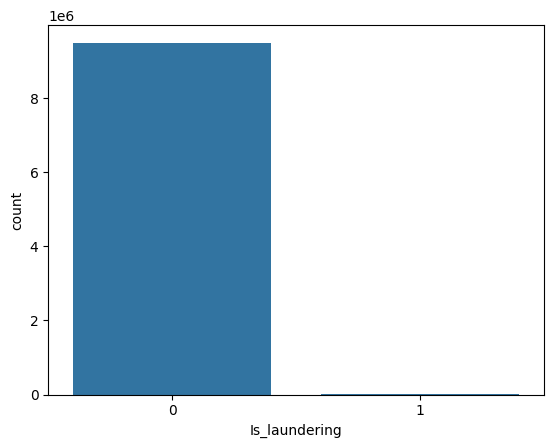

In [10]:
sns.countplot(data=df, x='Is_laundering')

In [11]:
df['Is_laundering'].value_counts()

Is_laundering
0    9494979
1       9873
Name: count, dtype: int64

## Data Visualizations

Laundering_type
Normal_Small_Fan_Out      3477717
Normal_Fan_Out            2302220
Normal_Fan_In             2104285
Normal_Group               528351
Normal_Cash_Withdrawal     305031
Normal_Cash_Deposits       223801
Normal_Periodical          210526
Normal_Plus_Mutual         155041
Normal_Mutual              125335
Normal_Foward               42031
Normal_single_large         20641
Structuring                  1870
Cash_Withdrawal              1334
Deposit-Send                  945
Smurfing                      932
Layered_Fan_In                656
Layered_Fan_Out               529
Stacked Bipartite             506
Behavioural_Change_1          394
Bipartite                     383
Cycle                         382
Fan_In                        364
Gather-Scatter                354
Behavioural_Change_2          345
Scatter-Gather                338
Single_large                  250
Fan_Out                       237
Over-Invoicing                 54
Name: count, dtype: int64

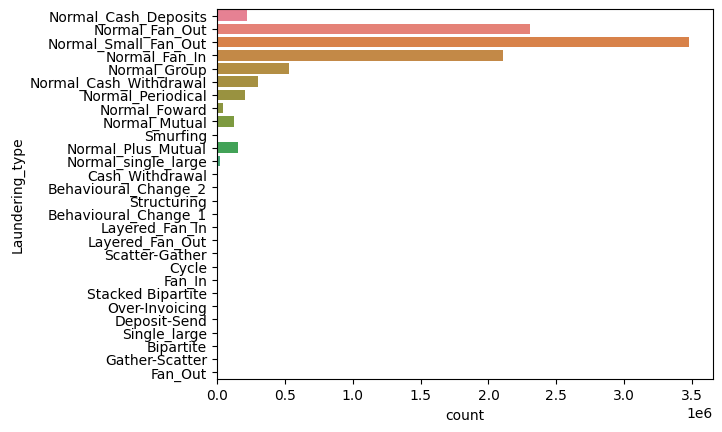

In [12]:
sns.countplot(data = df, y = 'Laundering_type', hue = 'Laundering_type')
df['Laundering_type'].value_counts()

<Axes: xlabel='Year', ylabel='count'>

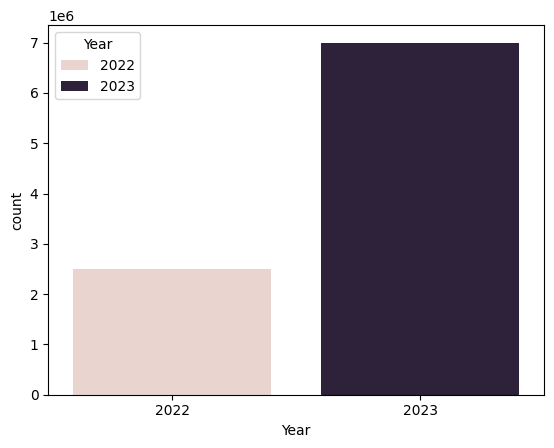

In [13]:
sns.countplot(data=df, x='Year', hue='Year')

<Axes: xlabel='Month', ylabel='count'>

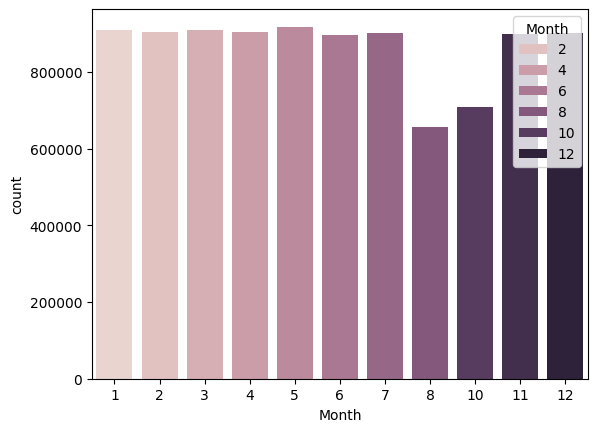

In [14]:
sns.countplot(data=df, x='Month', hue='Month')

<Axes: xlabel='count', ylabel='Day'>

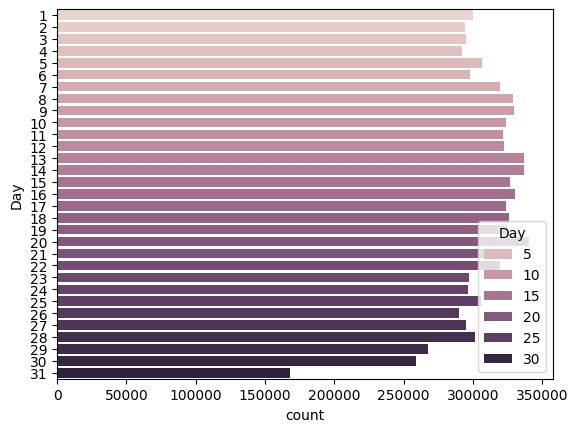

In [15]:
sns.countplot(data=df, y='Day', hue='Day')

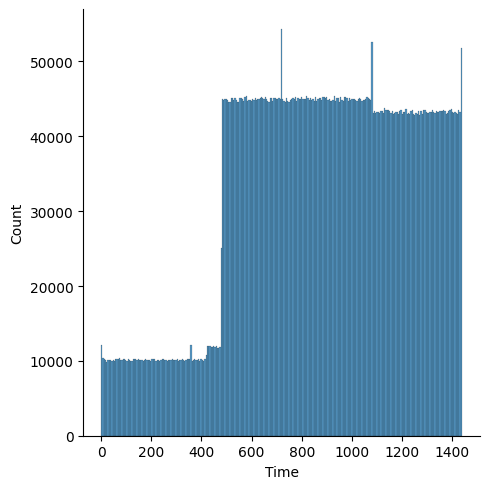

In [16]:
sns.displot(data=df, x='Time')

In [17]:
# sns.countplot(data=df, x = 'Source of Money')
df.columns

Index(['Time', 'Date', 'Sender_account', 'Receiver_account', 'Amount',
       'Payment_currency', 'Received_currency', 'Sender_bank_location',
       'Receiver_bank_location', 'Payment_type', 'Is_laundering',
       'Laundering_type', 'Year', 'Month', 'Week', 'Day'],
      dtype='object')

<Axes: xlabel='count', ylabel='Payment_type'>

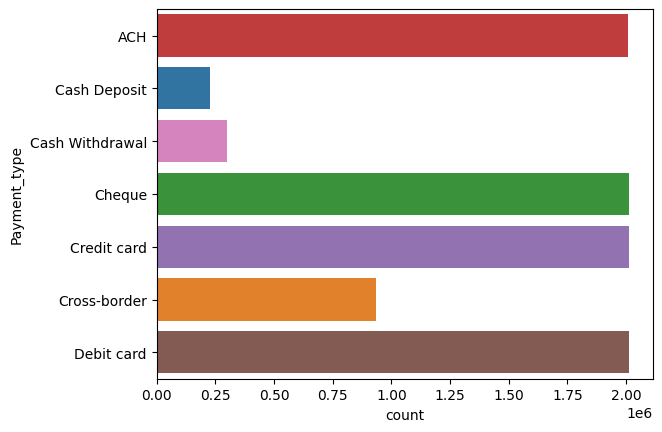

In [18]:
sns.countplot(data=df, y='Payment_type', hue='Payment_type', order=df['Payment_type'].sort_values().unique())

In [19]:
transactions_per_payment_type = df['Payment_type'].value_counts()

transactions_per_payment_type

Payment_type
Credit card        2012909
Debit card         2012103
Cheque             2011419
ACH                2008807
Cross-border        933931
Cash Withdrawal     300477
Cash Deposit        225206
Name: count, dtype: int64

In [20]:
laundering_transactions_per_payment_type = df[df['Is_laundering'] == 1].groupby('Payment_type').size()
laundering_transactions_per_payment_type

Payment_type
ACH                1159
Cash Deposit       1405
Cash Withdrawal    1334
Cheque             1087
Credit card        1136
Cross-border       2628
Debit card         1124
dtype: int64

In [21]:
laundering_transactions_per_payment_type = laundering_transactions_per_payment_type.reset_index()
laundering_transactions_per_payment_type.columns = ['Payment_type', 'Count']
laundering_transactions_per_payment_type

,Payment_type,Count
0,ACH,1159
1,Cash Deposit,1405
2,Cash Withdrawal,1334
3,Cheque,1087
4,Credit card,1136
5,Cross-border,2628
6,Debit card,1124


<Axes: xlabel='Count', ylabel='Payment_type'>

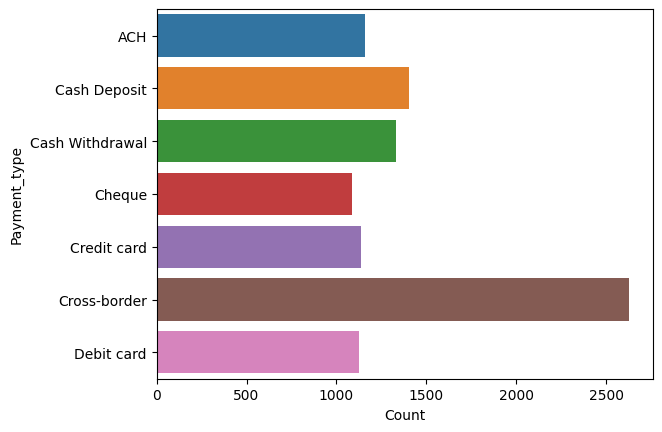

In [22]:
sns.barplot(data = laundering_transactions_per_payment_type.reset_index(), y='Payment_type', x='Count', hue='Payment_type')

In [23]:
# laundering_statistics = df[df['Is_laundering'] == 1]['Amount'].describe()
laundering_statistics = df[df['Is_laundering'] == 1]['Amount'].agg(['max', 'min', 'mean', 'std'])

print(laundering_statistics.apply(lambda x: f"{x:.2f}"))

max     12618498.40
min           15.82
mean       40587.67
std       419181.13
Name: Amount, dtype: object


In [24]:
not_aundering_statistics = df[df['Is_laundering'] == 0]['Amount'].agg(['max', 'min', 'mean', 'std'])

print(not_aundering_statistics.apply(lambda x: f"{x:.2f}"))

max     999962.19
min          3.73
mean      8729.88
std      21750.03
Name: Amount, dtype: object


In [ ]:

def lineplot(df: pd.DataFrame, agg_type: str):
    if agg_type == 'month':
        agg = 'M'
    elif agg_type == 'week':
        agg = 'W'
    elif agg_type == 'day':
        agg = 'D'
    elif agg_type == 'year':
        agg = 'Y'
    else:
        raise ValueError("Invalid aggregation type. Use 'month', 'week', 'day', or 'year'.")
        
    grouped_amounts = df.groupby(df['Date'].dt.to_period(agg))['Amount'].sum()
    mean_amounts = grouped_amounts.mean()

    grouped_transactions = df.groupby(df['Date'].dt.to_period(agg)).size()
    mean_transactions = grouped_transactions.mean()

    plt.figure(figsize=(12, 6))
    grouped_amounts.plot(kind='line')
    plt.axhline(y=mean_amounts, color='r', linestyle='--', label=f'Mean Amount {mean_amounts:.2f}')
    plt.title(f'Grouped amounts by {agg_type.capitalize()}')
    plt.xlabel('Date')
    plt.ylabel('Total Amount')
    plt.legend(loc='upper right')
    plt.grid(True)
    plt.show()

    plt.figure(figsize=(12, 6))
    grouped_transactions.plot(kind='line')
    plt.axhline(y=mean_transactions, color='r', linestyle='--', label=f'Mean Transactions {mean_transactions:.2f}')
    plt.title(f'Grouped transactions by {agg_type.capitalize()}')
    plt.xlabel('Date')
    plt.ylabel('Transaction Count')
    plt.legend(loc='upper right')
    plt.grid(True)
    plt.show()

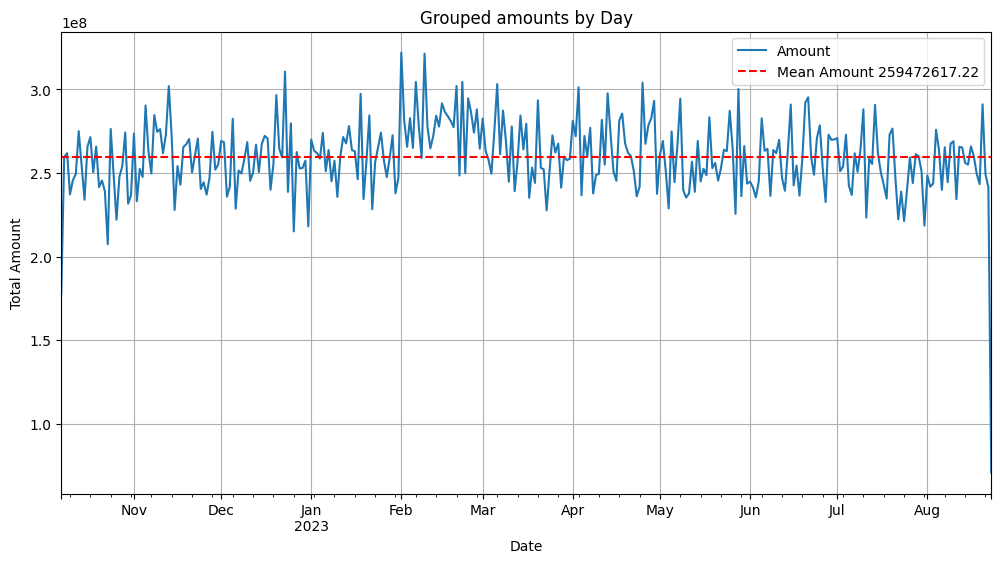

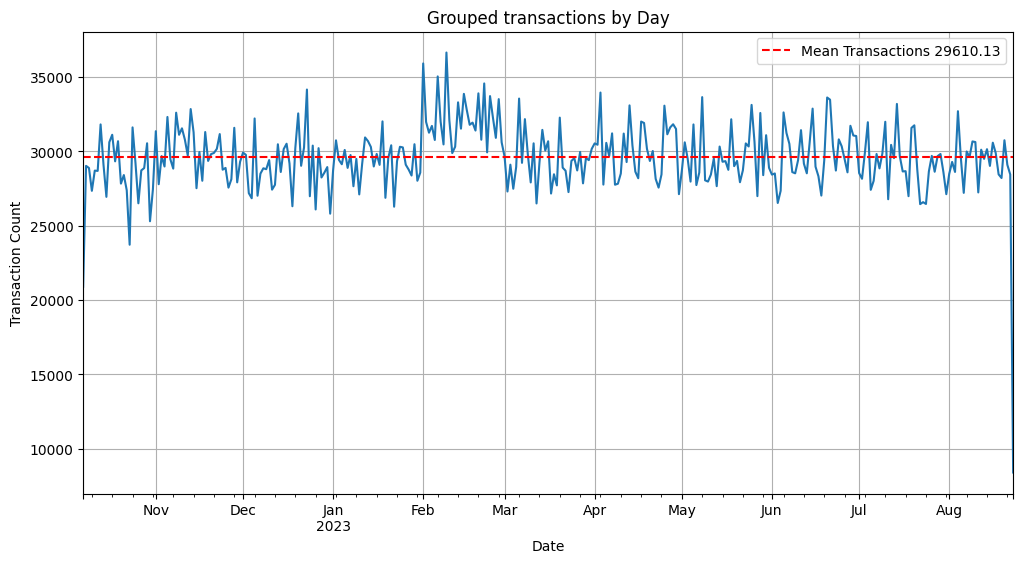

In [26]:
lineplot(df, 'day')

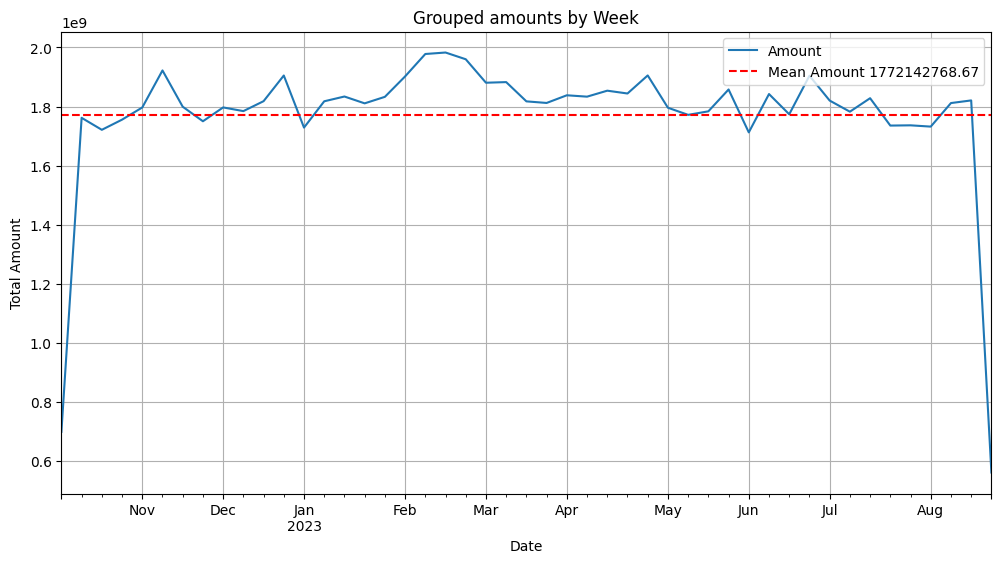

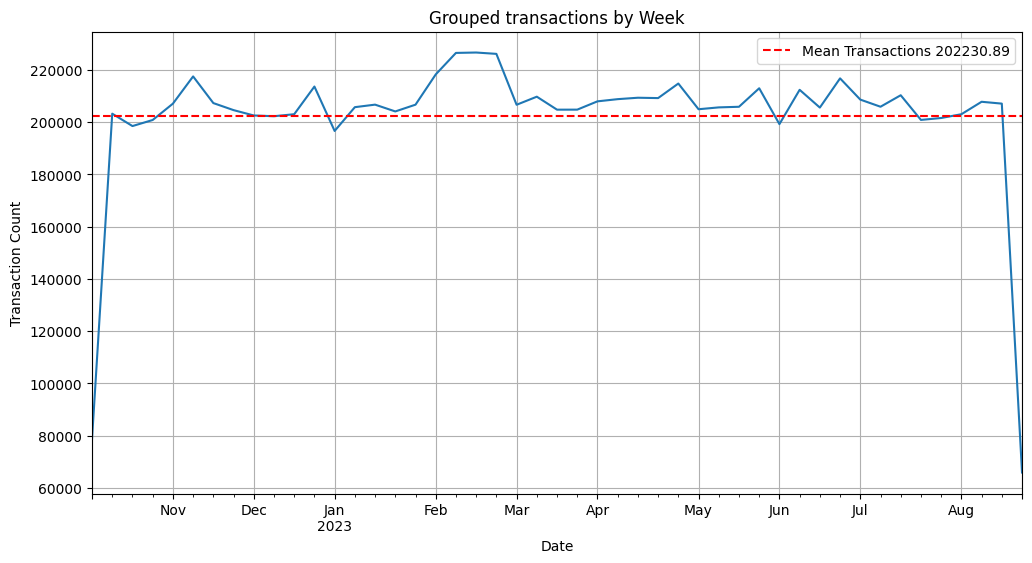

In [27]:
lineplot(df, 'week')

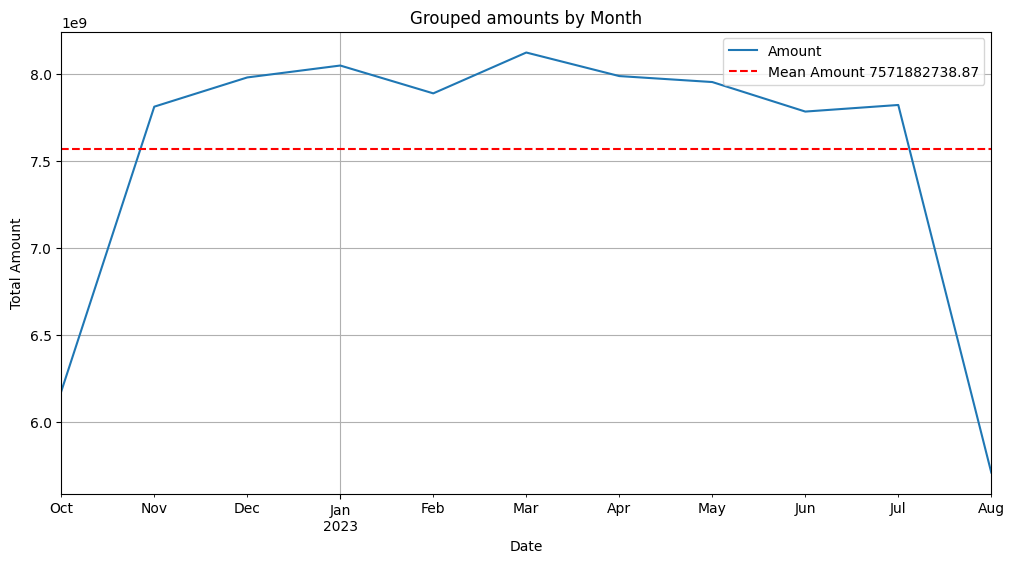

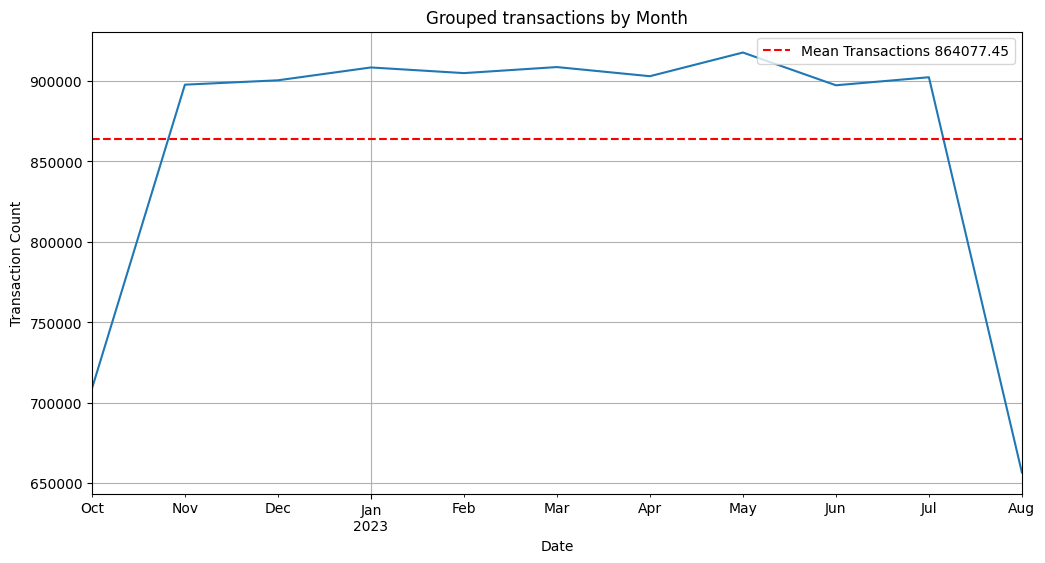

In [28]:
lineplot(df, 'month')

c:\Users\pawel.drzyzga\Documents\KursStreamlit\kursstreamlit\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


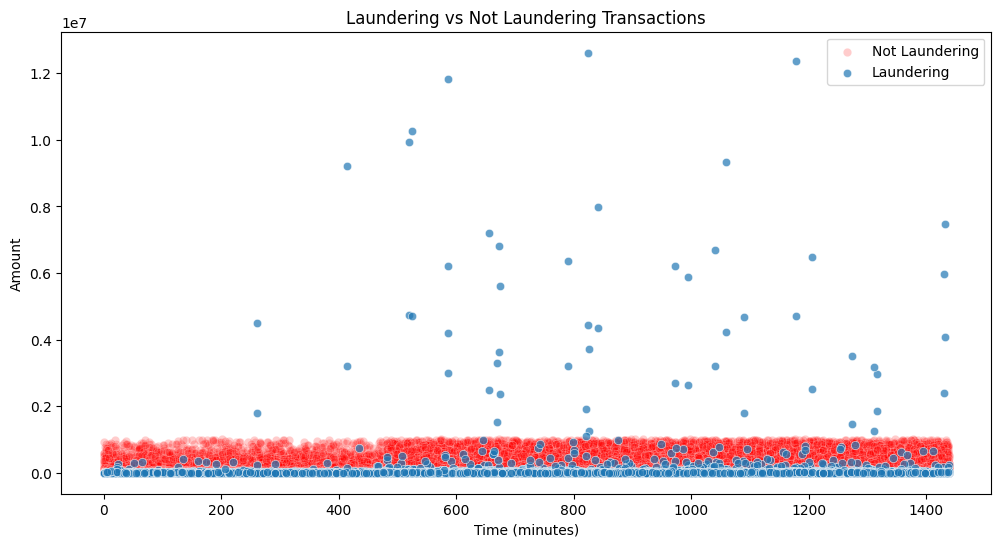

In [29]:
laundering = df[df['Is_laundering'] == 1]
not_laundering = df[df['Is_laundering'] == 0]

plt.figure(figsize=(12, 6))
sns.scatterplot(data=not_laundering, x='Time', y='Amount', alpha=0.2, color='red')
sns.scatterplot(data=laundering, x='Time', y='Amount', alpha=0.7)
plt.title('Laundering vs Not Laundering Transactions')
plt.xlabel('Time (minutes)')
plt.ylabel('Amount')
plt.legend(['Not Laundering', 'Laundering'])
plt.show()

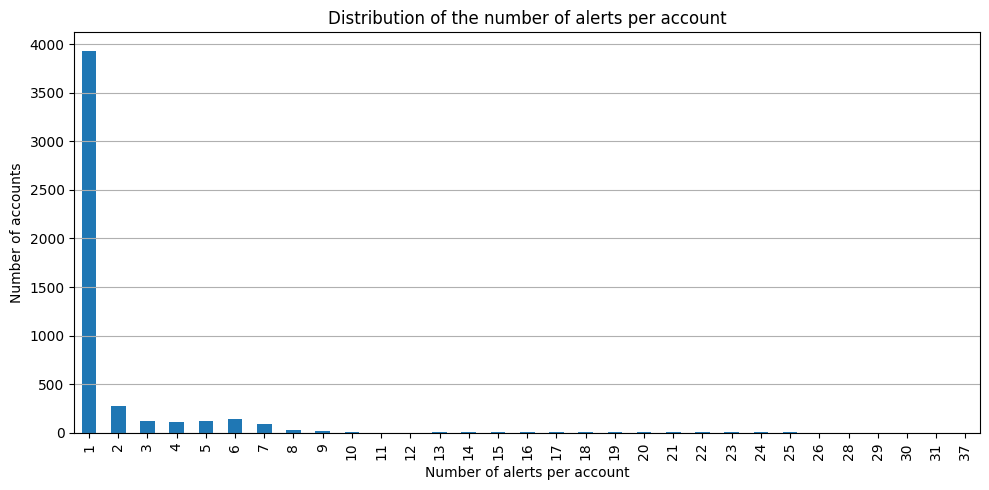

In [30]:
account_alert_counts = laundering.groupby('Sender_account').size()
alert_distribution = account_alert_counts.value_counts()
alert_distribution = alert_distribution.sort_index()

plt.figure(figsize=(10, 5))
alert_distribution.plot(kind='bar', figsize=(10, 5), title="Distribution of the number of alerts per account")
plt.xlabel("Number of alerts per account")
plt.ylabel("Number of accounts")
plt.grid(axis='y')
plt.tight_layout()
plt.show()

In [31]:
alert_distribution

1     3924
2      277
3      122
4      108
5      119
6      145
7       88
8       34
9       22
10      15
11       3
12       1
13       5
14       6
15       9
16       6
17       5
18       6
19       5
20       9
21       5
22       7
23       6
24       6
25       7
26       4
28       2
29       1
30       1
31       1
37       1
Name: count, dtype: int64

In [32]:
suspicious_account_37 = account_alert_counts[account_alert_counts == 37]

In [33]:
df[df['Sender_account'].isin(suspicious_account_37.index)][['Sender_account', 'Sender_bank_location','Receiver_account'
                                                            ,'Receiver_bank_location', 'Payment_type', 'Amount', 'Date'
                                                            , 'Time', 'Payment_type', 'Is_laundering', 'Laundering_type']]

,Sender_account,Sender_bank_location,Receiver_account,Receiver_bank_location,Payment_type,Amount,Date,Time,Payment_type,Is_laundering,Laundering_type
1190807,4159678387,UK,3757426467,UK,Cash Withdrawal,223.62,2022-11-16,1305,Cash Withdrawal,0,Normal_Cash_Withdrawal
2780268,4159678387,UK,270405806,UK,Cash Withdrawal,74.27,2023-01-10,755,Cash Withdrawal,1,Cash_Withdrawal
2782920,4159678387,UK,270405806,UK,Cash Withdrawal,211.88,2023-01-10,857,Cash Withdrawal,1,Cash_Withdrawal
2823169,4159678387,UK,270405806,UK,Cash Withdrawal,206.61,2023-01-11,1308,Cash Withdrawal,1,Cash_Withdrawal
2825004,4159678387,UK,270405806,UK,Cash Withdrawal,252.15,2023-01-11,1376,Cash Withdrawal,1,Cash_Withdrawal
2847449,4159678387,UK,270405806,UK,Cash Withdrawal,222.74,2023-01-12,1067,Cash Withdrawal,1,Cash_Withdrawal
2851802,4159678387,UK,270405806,UK,Cash Withdrawal,222.54,2023-01-12,1224,Cash Withdrawal,1,Cash_Withdrawal
2868453,4159678387,UK,270405806,UK,Cash Withdrawal,272.55,2023-01-13,740,Cash Withdrawal,1,Cash_Withdrawal
2887662,4159678387,UK,270405806,UK,Cash Withdrawal,111.65,2023-01-13,1414,Cash Withdrawal,1,Cash_Withdrawal
2899956,4159678387,UK,270405806,UK,Cash Withdrawal,310.58,2023-01-14,778,Cash Withdrawal,1,Cash_Withdrawal


In [34]:
suspicious_account_31 = account_alert_counts[account_alert_counts == 31]
df[df['Sender_account'].isin(suspicious_account_31.index)][['Sender_account', 'Sender_bank_location','Receiver_account'
                                                            ,'Receiver_bank_location', 'Payment_type', 'Amount', 'Date'
                                                            , 'Time', 'Payment_type', 'Is_laundering', 'Laundering_type']]

,Sender_account,Sender_bank_location,Receiver_account,Receiver_bank_location,Payment_type,Amount,Date,Time,Payment_type,Is_laundering,Laundering_type
1151992,9710838491,UK,93722998,Mexico,Cash Withdrawal,173.61,2022-11-15,941,Cash Withdrawal,1,Cash_Withdrawal
1164710,9710838491,UK,93722998,Mexico,Cash Withdrawal,221.37,2022-11-16,33,Cash Withdrawal,1,Cash_Withdrawal
1166472,9710838491,UK,93722998,Mexico,Cash Withdrawal,194.95,2022-11-16,313,Cash Withdrawal,1,Cash_Withdrawal
1197902,9710838491,UK,93722998,Mexico,Cash Withdrawal,198.10,2022-11-17,499,Cash Withdrawal,1,Cash_Withdrawal
1219498,9710838491,UK,93722998,Mexico,Cash Withdrawal,347.67,2022-11-17,1321,Cash Withdrawal,1,Cash_Withdrawal
1237055,9710838491,UK,93722998,Mexico,Cash Withdrawal,29.07,2022-11-18,858,Cash Withdrawal,1,Cash_Withdrawal
1249911,9710838491,UK,93722998,Mexico,Cash Withdrawal,18.76,2022-11-18,1301,Cash Withdrawal,1,Cash_Withdrawal
1271532,9710838491,UK,93722998,Mexico,Cash Withdrawal,98.00,2022-11-19,1016,Cash Withdrawal,1,Cash_Withdrawal
3578884,9710838491,UK,93722998,Mexico,Cash Withdrawal,189.06,2023-02-06,315,Cash Withdrawal,1,Cash_Withdrawal
3641474,9710838491,UK,93722998,Mexico,Cash Withdrawal,102.90,2023-02-07,1366,Cash Withdrawal,1,Cash_Withdrawal


## Skewness test

In [35]:
print(skew(df['Amount']))

102.16408577285024


In [36]:
log_amount = np.log1p(df['Amount'])
print(skew(log_amount))

-1.0103052224946008


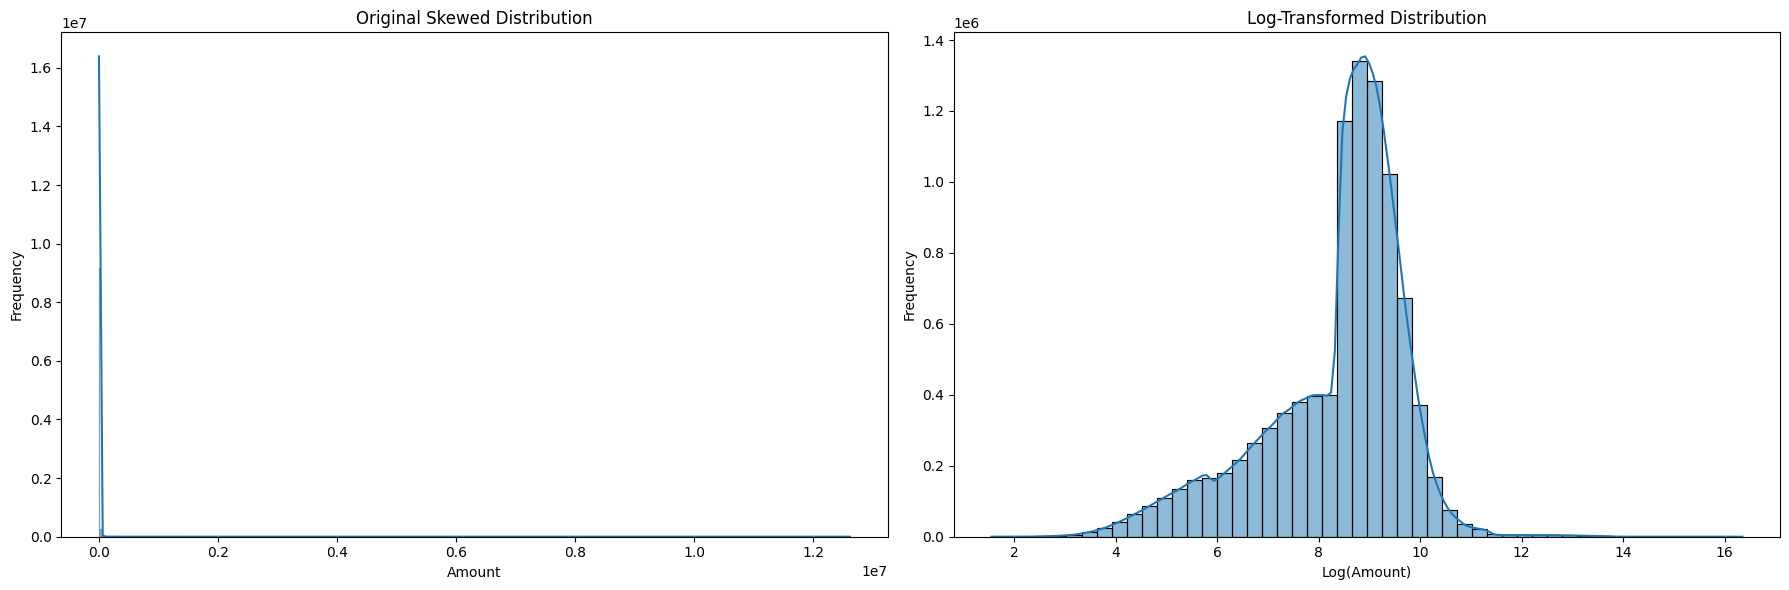

In [37]:
fig, ax = plt.subplots(1, 2, figsize=(18, 6))
sns.histplot(df['Amount'], bins=500, kde=True, ax=ax[0])
ax[0].set_title('Original Skewed Distribution')
ax[0].set_xlabel('Amount')
ax[0].set_ylabel('Frequency')

sns.histplot(np.log1p(df['Amount']), bins=50, kde=True, ax=ax[1])
ax[1].set_title('Log-Transformed Distribution')
ax[1].set_xlabel('Log(Amount)')
ax[1].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

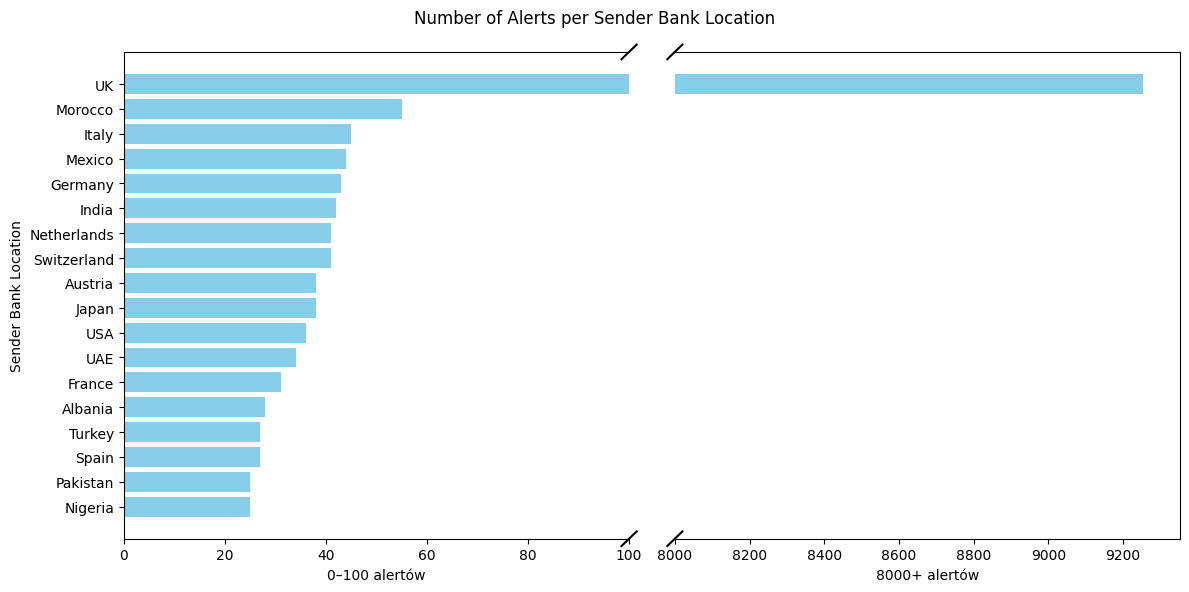

In [38]:
alerts_per_location = df.groupby('Sender_bank_location')['Is_laundering'].sum().reset_index()

alerts_per_location_sorted = alerts_per_location.sort_values('Is_laundering', ascending=True)
locations = alerts_per_location_sorted['Sender_bank_location']
alerts = alerts_per_location_sorted['Is_laundering']

fig, (ax1, ax2) = plt.subplots(1, 2, sharey=True, figsize=(12, 6))
fig.subplots_adjust(wspace=0.05)
fig.suptitle('Number of Alerts per Sender Bank Location')

ax1.barh(locations, alerts, color='skyblue')
ax1.set_xlim(0, 100)
ax1.set_xlabel('0–100 alertów')
ax1.set_ylabel('Sender Bank Location')
ax1.spines['right'].set_visible(False)
ax1.tick_params(right=False)

ax2.barh(locations, alerts, color='skyblue')
ax2.set_xlim(8000, alerts.max() + 100)
ax2.set_xlabel('8000+ alertów')
ax2.spines['left'].set_visible(False)
ax2.tick_params(left=False, labelleft=False)

d = .015  
kwargs = dict(transform=ax1.transAxes, color='k', clip_on=False)
ax1.plot((1 - d, 1 + d), (-d, +d), **kwargs)
ax1.plot((1 - d, 1 + d), (1 - d, 1 + d), **kwargs)

kwargs.update(transform=ax2.transAxes)
ax2.plot((-d, +d), (-d, +d), **kwargs)
ax2.plot((-d, +d), (1 - d, 1 + d), **kwargs)

plt.tight_layout()
plt.show()


## Preparing data and preprocessing

In [39]:
df.columns

Index(['Time', 'Date', 'Sender_account', 'Receiver_account', 'Amount',
       'Payment_currency', 'Received_currency', 'Sender_bank_location',
       'Receiver_bank_location', 'Payment_type', 'Is_laundering',
       'Laundering_type', 'Year', 'Month', 'Week', 'Day'],
      dtype='object')

In [40]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9504852 entries, 0 to 9504851
Data columns (total 16 columns):
 #   Column                  Dtype         
---  ------                  -----         
 0   Time                    int64         
 1   Date                    datetime64[ns]
 2   Sender_account          int64         
 3   Receiver_account        int64         
 4   Amount                  float64       
 5   Payment_currency        object        
 6   Received_currency       object        
 7   Sender_bank_location    object        
 8   Receiver_bank_location  object        
 9   Payment_type            object        
 10  Is_laundering           int64         
 11  Laundering_type         object        
 12  Year                    int32         
 13  Month                   int32         
 14  Week                    UInt32        
 15  Day                     int32         
dtypes: UInt32(1), datetime64[ns](1), float64(1), int32(3), int64(4), object(6)
memory usage: 1

In [41]:
df.count()

Time                      9504852
Date                      9504852
Sender_account            9504852
Receiver_account          9504852
Amount                    9504852
Payment_currency          9504852
Received_currency         9504852
Sender_bank_location      9504852
Receiver_bank_location    9504852
Payment_type              9504852
Is_laundering             9504852
Laundering_type           9504852
Year                      9504852
Month                     9504852
Week                      9504852
Day                       9504852
dtype: int64

In [42]:
df_sampled, _ = train_test_split(df, 
                                 train_size=0.05, 
                                 stratify=df["Is_laundering"], 
                                 random_state=42)

In [43]:
df['Is_laundering'].value_counts(), df_sampled['Is_laundering'].value_counts()

(Is_laundering
 0    9494979
 1       9873
 Name: count, dtype: int64,
 Is_laundering
 0    474748
 1       494
 Name: count, dtype: int64)

In [6]:
X = df_sampled.drop(columns=['Is_laundering'])
y = df_sampled['Is_laundering']

In [7]:
del df

In [8]:
X[['Time','Year','Month','Week','Day']] = X[['Time','Year','Month','Week','Day']].astype('Int16')

In [9]:
X.drop(columns=['Date', 'Time'], inplace=True)
X.info()

<class 'pandas.core.frame.DataFrame'>
Index: 475242 entries, 2662856 to 7180925
Data columns (total 13 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   Sender_account          475242 non-null  int64  
 1   Receiver_account        475242 non-null  int64  
 2   Amount                  475242 non-null  float64
 3   Payment_currency        475242 non-null  object 
 4   Received_currency       475242 non-null  object 
 5   Sender_bank_location    475242 non-null  object 
 6   Receiver_bank_location  475242 non-null  object 
 7   Payment_type            475242 non-null  object 
 8   Laundering_type         475242 non-null  object 
 9   Year                    475242 non-null  Int16  
 10  Month                   475242 non-null  Int16  
 11  Week                    475242 non-null  Int16  
 12  Day                     475242 non-null  Int16  
dtypes: Int16(4), float64(1), int64(2), object(6)
memory usage: 41.7+ MB


In [10]:
X.select_dtypes(include=['object']).columns

Index(['Payment_currency', 'Received_currency', 'Sender_bank_location',
       'Receiver_bank_location', 'Payment_type', 'Laundering_type'],
      dtype='object')

In [11]:
X.select_dtypes(exclude=['object']).columns

Index(['Sender_account', 'Receiver_account', 'Amount', 'Year', 'Month', 'Week',
       'Day'],
      dtype='object')

In [45]:
# X.to_csv('X.csv', index=False)
# y.to_csv('y.csv', index=False)

X = pd.read_csv('X.csv')
y = pd.read_csv('y.csv')

In [46]:
num_cols = X.select_dtypes(exclude=['object']).columns
cat_cols = X.select_dtypes(include=['object']).columns

## Finding best model and model val

In [47]:
# Pipeline dla danych liczbowych
num_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", RobustScaler())
])

# Pipeline dla danych kategorycznych
cat_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1))
])

# ColumnTransformer
preprocessor = ColumnTransformer([
    ("num", num_pipeline, num_cols),
    ("cat", cat_pipeline, cat_cols)
])

model_pipeline = Pipeline([
    ("preprocessing", preprocessor),
    ("classifier", RandomForestClassifier(random_state=42, n_jobs=-1))
])

In [48]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [49]:
del X, y

In [17]:
model_pipeline.fit(X_train, y_train)

Pipeline(steps=[('preprocessing',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   RobustScaler())]),
                                                  Index(['Sender_account', 'Receiver_account', 'Amount', 'Year', 'Month', 'Week',
       'Day'],
      dtype='object')),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OrdinalEncoder(handle_unknown='use_encoded_value',
                                                                                  unknown_value=-1))]),
                                                  Index(['Payment_currency', 'Received_currency', 'Sender_bank_location',
       'Receiver_bank_location', 'Payment_type', 'Laundering_type'],
      dtype='object'))])),
                ('classifier',
                 RandomForestClassifier(n_jobs=-1, random_state=42))])

In [18]:
y_pred = model_pipeline.predict(X_test)
y_proba = model_pipeline.predict_proba(X_test)[:, 1]
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     94950
           1       1.00      1.00      1.00        99

    accuracy                           1.00     95049
   macro avg       1.00      1.00      1.00     95049
weighted avg       1.00      1.00      1.00     95049



              precision    recall  f1-score   support

           0       1.00      0.84      0.91     94950
           1       0.00      0.60      0.01        99

    accuracy                           0.84     95049
   macro avg       0.50      0.72      0.46     95049
weighted avg       1.00      0.84      0.91     95049



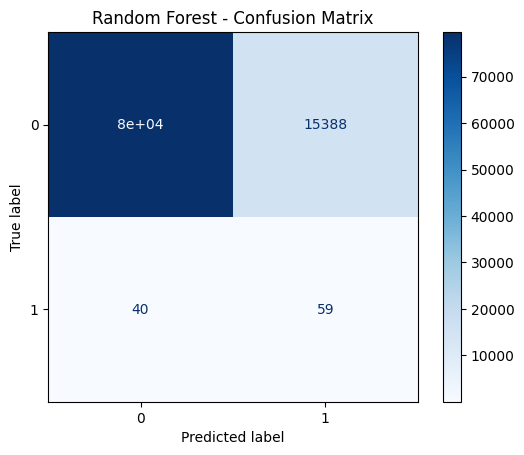

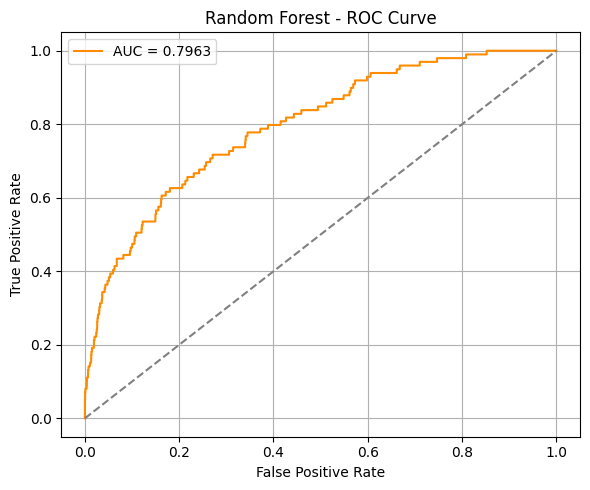

ROC AUC Score: 0.7963
GINI: 0.5927


In [147]:
evaluate_model(y_test, y_pred, y_proba, model_name="Random Forest")

In [20]:
model_pipeline.named_steps['classifier'].feature_importances_

array([1.87074587e-02, 1.89015689e-02, 2.36786757e-02, 8.19437450e-04,
       2.42847732e-03, 4.27390999e-03, 4.98526911e-03, 2.10673746e-03,
       2.80172830e-03, 1.97222139e-03, 3.42044945e-03, 7.64142339e-03,
       9.08262643e-01])

In [ ]:
def get_feature_names(preprocessor, numerical_features, categorical_features):
    feature_names = []

    for name, transformer, cols in preprocessor.transformers_:
        if name == 'remainder' and transformer == 'passthrough':
            feature_names.extend(cols)
        elif hasattr(transformer, 'named_steps'):
            last_step = list(transformer.named_steps.values())[-1]
            if hasattr(last_step, 'get_feature_names_out'):
                try:
                    names = last_step.get_feature_names_out(cols)
                    feature_names.extend(names)
                except:
                    feature_names.extend(cols)
            else:
                feature_names.extend(cols)
        else:
            feature_names.extend(cols)
    return feature_names


In [22]:
feature_names = get_feature_names(
    preprocessor=model_pipeline.named_steps["preprocessing"],
    numerical_features=num_cols,
    categorical_features=cat_cols
)

In [23]:
feature_names

['Sender_account',
 'Receiver_account',
 'Amount',
 'Year',
 'Month',
 'Week',
 'Day',
 'Payment_currency',
 'Received_currency',
 'Sender_bank_location',
 'Receiver_bank_location',
 'Payment_type',
 'Laundering_type']

In [24]:
importances = model_pipeline.named_steps["classifier"].feature_importances_

# Tworzymy DataFrame z nazwami i wagami
importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importances
}).sort_values(by="Importance", ascending=False)

print(importance_df)

                   Feature  Importance
12         Laundering_type    0.908263
2                   Amount    0.023679
1         Receiver_account    0.018902
0           Sender_account    0.018707
11            Payment_type    0.007641
6                      Day    0.004985
5                     Week    0.004274
10  Receiver_bank_location    0.003420
8        Received_currency    0.002802
4                    Month    0.002428
7         Payment_currency    0.002107
9     Sender_bank_location    0.001972
3                     Year    0.000819


## Kicking out a Laundering_type, to make a scenario harder

In [51]:
X_train_notype = X_train.drop('Laundering_type', axis=1)

In [26]:
X_train_notype

,Sender_account,Receiver_account,Amount,Payment_currency,Received_currency,Sender_bank_location,Receiver_bank_location,Payment_type,Year,Month,Week,Day
6724845,372595155,6163750657,1432.89,UK pounds,UK pounds,UK,UK,Cheque,2023,5,20,21
109544,5270923399,3927673632,1233.55,UK pounds,UK pounds,UK,UK,Cash Deposit,2022,10,41,11
6255059,761315222,7434414385,11094.75,Euro,UK pounds,Netherlands,UK,Cross-border,2023,5,18,5
3107379,6207611402,2060989738,7728.99,UK pounds,UK pounds,UK,UK,Debit card,2023,1,3,21
2126748,1988844117,3140842569,14908.92,UK pounds,UK pounds,UK,UK,ACH,2022,12,51,19
...,...,...,...,...,...,...,...,...,...,...,...,...
8104232,5228281820,2844713353,11224.15,UK pounds,UK pounds,UK,UK,ACH,2023,7,27,6
79751,4387758648,5601193795,7626.47,UK pounds,UK pounds,UK,UK,Credit card,2022,10,41,10
7208956,3467915237,7401798853,4879.82,UK pounds,UK pounds,UK,UK,Debit card,2023,6,23,6
8835967,7398885952,5580316799,6872.08,UK pounds,UK pounds,UK,UK,Cheque,2023,7,31,31


In [ ]:
num_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", RobustScaler())
])

cat_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1))
])

preprocessor = ColumnTransformer([
    ("num", num_pipeline, num_cols),
    ("cat", cat_pipeline, X_train_notype.select_dtypes(include=['object']).columns)
])

model_pipeline_2 = Pipeline([
    ("preprocessing", preprocessor),
    ("classifier", RandomForestClassifier(random_state=42, n_jobs=-1))
])

model_pipeline_2.fit(X_train_notype, y_train)

Pipeline(steps=[('preprocessing',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   RobustScaler())]),
                                                  Index(['Sender_account', 'Receiver_account', 'Amount', 'Year', 'Month', 'Week',
       'Day'],
      dtype='object')),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OrdinalEncoder(handle_unknown='use_encoded_value',
                                                                                  unknown_value=-1))]),
                                                  Index(['Payment_currency', 'Received_currency', 'Sender_bank_location',
       'Receiver_bank_location', 'Payment_type'],
      dtype='object'))])),
                ('classifier',
                 RandomForestClassifier(n_jobs=-1, random_state=42))])

              precision    recall  f1-score   support

           0       1.00      1.00      1.00    379798
           1       1.00      1.00      1.00       395

    accuracy                           1.00    380193
   macro avg       1.00      1.00      1.00    380193
weighted avg       1.00      1.00      1.00    380193

              precision    recall  f1-score   support

           0       1.00      1.00      1.00    379798
           1       1.00      1.00      1.00       395

    accuracy                           1.00    380193
   macro avg       1.00      1.00      1.00    380193
weighted avg       1.00      1.00      1.00    380193



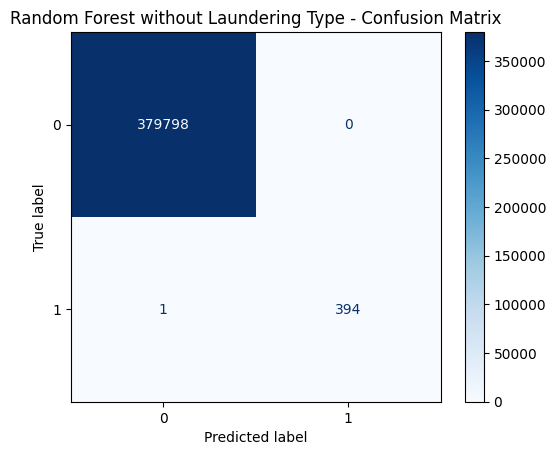

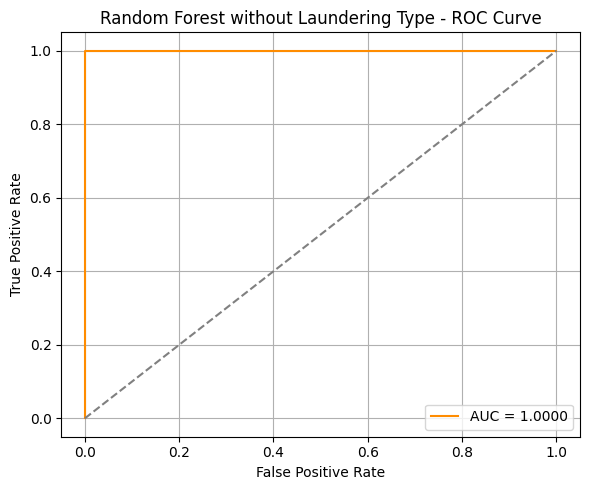

ROC AUC Score: 1.0000
GINI: 1.0000


In [28]:
y_pred = model_pipeline_2.predict(X_train_notype)
y_proba = model_pipeline_2.predict_proba(X_train_notype)[:, 1]

print(classification_report(y_train, y_pred))

evaluate_model(y_train, y_pred, y_proba, model_name="Random Forest without Laundering Type")

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     94950
           1       1.00      0.05      0.10        99

    accuracy                           1.00     95049
   macro avg       1.00      0.53      0.55     95049
weighted avg       1.00      1.00      1.00     95049

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     94950
           1       1.00      0.05      0.10        99

    accuracy                           1.00     95049
   macro avg       1.00      0.53      0.55     95049
weighted avg       1.00      1.00      1.00     95049



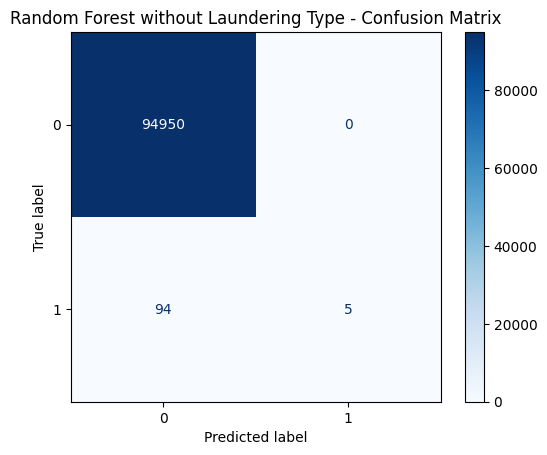

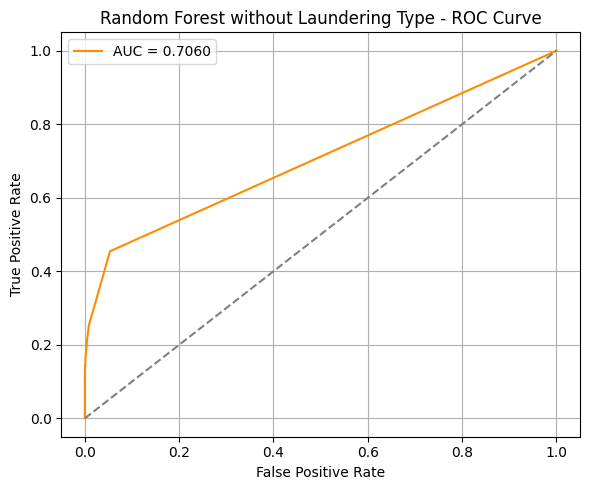

ROC AUC Score: 0.7060
GINI: 0.4121


In [29]:
y_pred = model_pipeline_2.predict(X_test.drop('Laundering_type', axis=1))
y_proba = model_pipeline_2.predict_proba(X_test.drop('Laundering_type', axis=1))[:, 1]
print(classification_report(y_test, y_pred))

evaluate_model(y_test, y_pred, y_proba, model_name="Random Forest without Laundering Type")

In [30]:
model_pipeline_3 = Pipeline([
    ("preprocessing", preprocessor),
    ("classifier", RandomForestClassifier(random_state=42, n_jobs=-1))
])

param_grid = {
    'classifier__n_estimators': [100, 200],
    'classifier__max_depth': [10, 20, None],
    'classifier__min_samples_split': [2, 5]
}

grid_search = GridSearchCV(
    estimator=model_pipeline_3,
    param_grid=param_grid,
    cv=5,
    scoring='roc_auc',
    verbose=2,
    n_jobs=-1 
)

In [31]:
grid_search.fit(X_train_notype, y_train)

Fitting 5 folds for each of 12 candidates, totalling 60 fits


GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('preprocessing',
                                        ColumnTransformer(transformers=[('num',
                                                                         Pipeline(steps=[('imputer',
                                                                                          SimpleImputer(strategy='median')),
                                                                                         ('scaler',
                                                                                          RobustScaler())]),
                                                                         Index(['Sender_account', 'Receiver_account', 'Amount', 'Year', 'Month', 'Week',
       'Day'],
      dtype='object')),
                                                                        ('cat',
                                                                         Pipeline(steps=[('imputer',
                                                                                          SimpleImputer(strategy='most_...
                                                                         Index(['Payment_currency', 'Received_currency', 'Sender_bank_location',
       'Receiver_bank_location', 'Payment_type'],
      dtype='object'))])),
                                       ('classifier',
                                        RandomForestClassifier(n_jobs=-1,
                                                               random_state=42))]),
             n_jobs=-1,
             param_grid={'classifier__max_depth': [10, 20, None],
                         'classifier__min_samples_split': [2, 5],
                         'classifier__n_estimators': [100, 200]},
             scoring='roc_auc', verbose=2)

In [32]:
grid_search.best_params_

{'classifier__max_depth': 10,
 'classifier__min_samples_split': 5,
 'classifier__n_estimators': 200}

In [37]:
pd.DataFrame(grid_search.cv_results_)

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_classifier__max_depth,param_classifier__min_samples_split,param_classifier__n_estimators,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score
0,193.588903,22.536771,25.475093,1.686025,10,2,100,"{'classifier__max_depth': 10, 'classifier__min...",0.811060,0.764868,0.769228,0.769638,0.816781,0.786315,0.022674,4
1,398.791889,16.396074,26.192100,0.347401,10,2,200,"{'classifier__max_depth': 10, 'classifier__min...",0.808494,0.776023,0.776305,0.803315,0.824803,0.797788,0.019027,2
2,254.906204,15.552717,22.751642,2.073133,10,5,100,"{'classifier__max_depth': 10, 'classifier__min...",0.798150,0.767117,0.760732,0.825562,0.807514,0.791815,0.024502,3
3,438.688608,6.239586,19.891917,4.969241,10,5,200,"{'classifier__max_depth': 10, 'classifier__min...",0.810421,0.788754,0.766793,0.835481,0.819728,0.804235,0.024067,1
4,341.360046,5.050812,22.487121,5.477852,20,2,100,"{'classifier__max_depth': 20, 'classifier__min...",0.660423,0.651808,0.737044,0.703417,0.626071,0.675753,0.039493,12
5,554.580360,9.877700,20.818830,4.617898,20,2,200,"{'classifier__max_depth': 20, 'classifier__min...",0.692440,0.664012,0.748130,0.724496,0.682774,0.702370,0.030125,10
6,328.934360,14.886455,21.669416,5.267119,20,5,100,"{'classifier__max_depth': 20, 'classifier__min...",0.715562,0.683048,0.729208,0.742488,0.727708,0.719603,0.020171,7
7,537.596574,7.871997,26.207388,3.059054,20,5,200,"{'classifier__max_depth': 20, 'classifier__min...",0.731702,0.730534,0.741914,0.756289,0.745870,0.741262,0.009528,5
8,313.353019,18.858721,26.349809,5.387042,None,2,100,"{'classifier__max_depth': None, 'classifier__m...",0.700271,0.656211,0.715029,0.702875,0.692831,0.693443,0.019941,11
9,539.642827,10.032600,15.424773,3.818165,None,2,200,"{'classifier__max_depth': None, 'classifier__m...",0.709668,0.702767,0.713044,0.712711,0.720092,0.711656,0.005607,8


              precision    recall  f1-score   support

           0       1.00      1.00      1.00     94950
           1       1.00      0.04      0.08        99

    accuracy                           1.00     95049
   macro avg       1.00      0.52      0.54     95049
weighted avg       1.00      1.00      1.00     95049



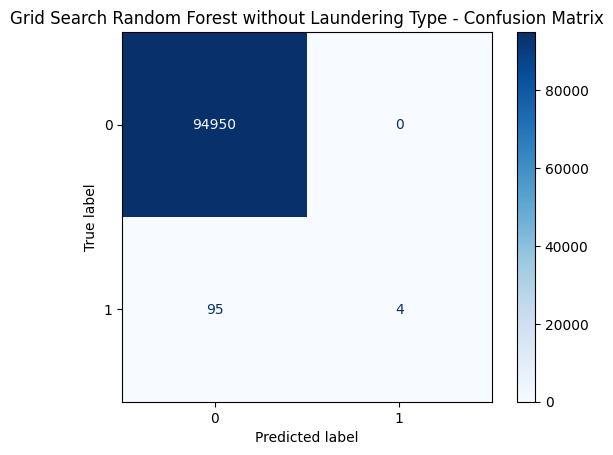

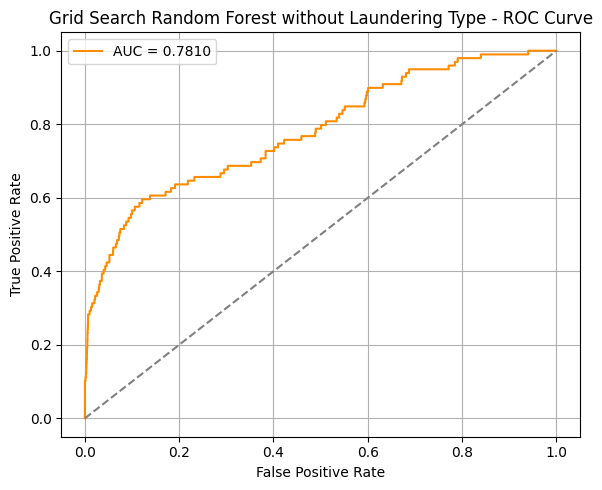

ROC AUC Score: 0.7810
GINI: 0.5619


In [35]:
y_pred = grid_search.predict(X_test.drop('Laundering_type', axis=1))
y_proba = grid_search.predict_proba(X_test.drop('Laundering_type', axis=1))[:, 1]
evaluate_model(y_test, y_pred, y_proba, model_name="Grid Search Random Forest without Laundering Type")

In [39]:
model_pipeline_3 = Pipeline([
    ("preprocessing", preprocessor),
    ("classifier", RandomForestClassifier(random_state=42, n_jobs=-1))
])

param_grid = {
    'classifier__n_estimators': [50, 200, 500],
    'classifier__max_depth': [3,5,8],
    'classifier__min_samples_split': [5, 10, 20]
}

grid_search = GridSearchCV(
    estimator=model_pipeline_3,
    param_grid=param_grid,
    cv=5,
    scoring='roc_auc',
    verbose=2,
    n_jobs=-1 
)

grid_search.fit(X_train_notype, y_train)

Fitting 5 folds for each of 27 candidates, totalling 135 fits


GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('preprocessing',
                                        ColumnTransformer(transformers=[('num',
                                                                         Pipeline(steps=[('imputer',
                                                                                          SimpleImputer(strategy='median')),
                                                                                         ('scaler',
                                                                                          RobustScaler())]),
                                                                         Index(['Sender_account', 'Receiver_account', 'Amount', 'Year', 'Month', 'Week',
       'Day'],
      dtype='object')),
                                                                        ('cat',
                                                                         Pipeline(steps=[('imputer',
                                                                                          SimpleImputer(strategy='most_...
                                                                         Index(['Payment_currency', 'Received_currency', 'Sender_bank_location',
       'Receiver_bank_location', 'Payment_type'],
      dtype='object'))])),
                                       ('classifier',
                                        RandomForestClassifier(n_jobs=-1,
                                                               random_state=42))]),
             n_jobs=-1,
             param_grid={'classifier__max_depth': [3, 5, 8],
                         'classifier__min_samples_split': [5, 10, 20],
                         'classifier__n_estimators': [50, 200, 500]},
             scoring='roc_auc', verbose=2)

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     94950
           1       1.00      0.02      0.04        99

    accuracy                           1.00     95049
   macro avg       1.00      0.51      0.52     95049
weighted avg       1.00      1.00      1.00     95049



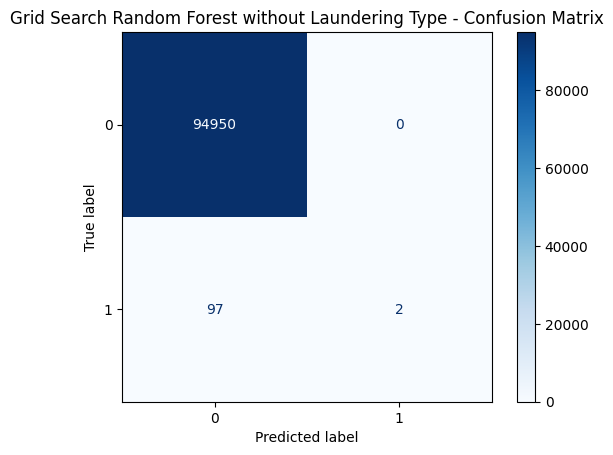

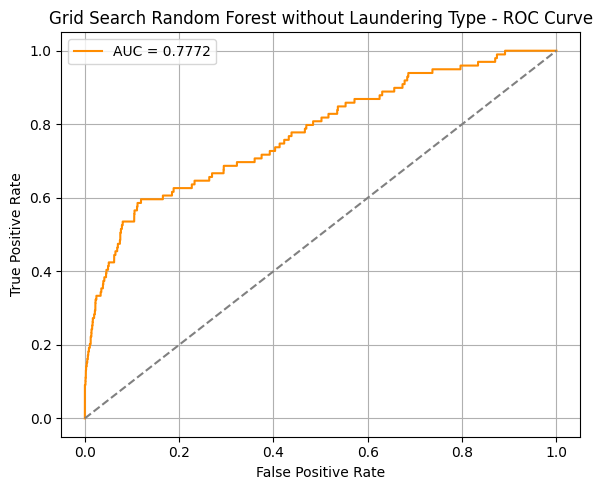

ROC AUC Score: 0.7772
GINI: 0.5544


In [42]:
y_pred = grid_search.predict(X_test.drop('Laundering_type', axis=1))
y_proba = grid_search.predict_proba(X_test.drop('Laundering_type', axis=1))[:, 1]
evaluate_model(y_test, y_pred, y_proba, model_name="Grid Search Random Forest without Laundering Type")

In [12]:
model_pipeline_3 = Pipeline([
    ("preprocessing", preprocessor),
    ("classifier", RandomForestClassifier(random_state=42, n_jobs=-1))
])

param_grid = {
    'classifier__n_estimators': [50, 100, 200],
    'classifier__max_depth': [6,8, 10],
    'classifier__min_samples_split': [15, 30, 45]
}

grid_search = GridSearchCV(
    estimator=model_pipeline_3,
    param_grid=param_grid,
    cv=5,
    scoring='roc_auc',
    verbose=3,
    n_jobs=-1 
)

grid_search.fit(X_train_notype, y_train)

Fitting 5 folds for each of 27 candidates, totalling 135 fits


c:\Users\pawel.drzyzga\Documents\KursStreamlit\kursstreamlit\lib\site-packages\sklearn\base.py:1389: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('preprocessing',
                                        ColumnTransformer(transformers=[('num',
                                                                         Pipeline(steps=[('imputer',
                                                                                          SimpleImputer(strategy='median')),
                                                                                         ('scaler',
                                                                                          RobustScaler())]),
                                                                         Index(['Sender_account', 'Receiver_account', 'Amount', 'Year', 'Month', 'Week',
       'Day'],
      dtype='object')),
                                                                        ('cat',
                                                                         Pipeline(steps=[('imputer',
                                                                                          SimpleImputer(strategy='most_...
                                                                         Index(['Payment_currency', 'Received_currency', 'Sender_bank_location',
       'Receiver_bank_location', 'Payment_type'],
      dtype='object'))])),
                                       ('classifier',
                                        RandomForestClassifier(n_jobs=-1,
                                                               random_state=42))]),
             n_jobs=-1,
             param_grid={'classifier__max_depth': [6, 8, 10],
                         'classifier__min_samples_split': [15, 30, 45],
                         'classifier__n_estimators': [50, 100, 200]},
             scoring='roc_auc', verbose=3)

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     94950
           1       1.00      0.04      0.08        99

    accuracy                           1.00     95049
   macro avg       1.00      0.52      0.54     95049
weighted avg       1.00      1.00      1.00     95049



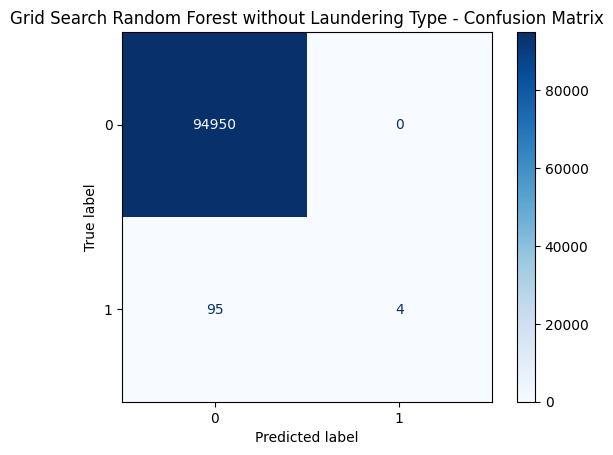

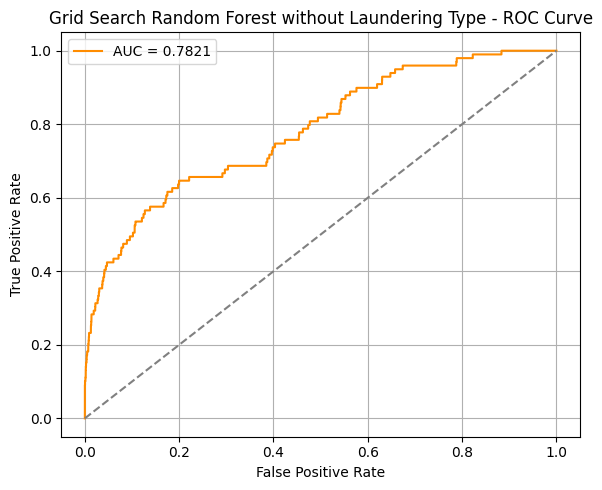

ROC AUC Score: 0.7821
GINI: 0.5641


In [13]:
y_pred = grid_search.predict(X_test.drop('Laundering_type', axis=1))
y_proba = grid_search.predict_proba(X_test.drop('Laundering_type', axis=1))[:, 1]
evaluate_model(y_test, y_pred, y_proba, model_name="Grid Search Random Forest without Laundering Type")

In [ ]:
model_pipeline_3 = Pipeline([
    ("preprocessing", preprocessor),
    ("classifier", RandomForestClassifier(random_state=42, n_jobs=-1))
])

param_grid = {
    'classifier__n_estimators': [100, 200, 300],
    'classifier__max_depth': [5,10, 15],
    'classifier__min_samples_split': [30, 45, 60]
}

grid_search = GridSearchCV(
    estimator=model_pipeline_3,
    param_grid=param_grid,
    cv=5,
    scoring='roc_auc',
    verbose=3,
    n_jobs=-1 
)

grid_search.fit(X_train_notype, y_train)

Fitting 5 folds for each of 27 candidates, totalling 135 fits


c:\Users\pawel.drzyzga\Documents\KursStreamlit\kursstreamlit\lib\site-packages\sklearn\base.py:1389: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('preprocessing',
                                        ColumnTransformer(transformers=[('num',
                                                                         Pipeline(steps=[('imputer',
                                                                                          SimpleImputer(strategy='median')),
                                                                                         ('scaler',
                                                                                          RobustScaler())]),
                                                                         Index(['Sender_account', 'Receiver_account', 'Amount', 'Year', 'Month', 'Week',
       'Day'],
      dtype='object')),
                                                                        ('cat',
                                                                         Pipeline(steps=[('imputer',
                                                                                          SimpleImputer(strategy='most_...
                                                                         Index(['Payment_currency', 'Received_currency', 'Sender_bank_location',
       'Receiver_bank_location', 'Payment_type'],
      dtype='object'))])),
                                       ('classifier',
                                        RandomForestClassifier(n_jobs=-1,
                                                               random_state=42))]),
             n_jobs=-1,
             param_grid={'classifier__max_depth': [5, 10, 15],
                         'classifier__min_samples_split': [30, 45, 60],
                         'classifier__n_estimators': [100, 200, 300]},
             scoring='roc_auc', verbose=3)

In [11]:
grid_search.best_score_, grid_search.best_params_

(np.float64(0.8119263437020001),
 {'classifier__max_depth': 15,
  'classifier__min_samples_split': 45,
  'classifier__n_estimators': 300})

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     94950
           1       1.00      0.04      0.08        99

    accuracy                           1.00     95049
   macro avg       1.00      0.52      0.54     95049
weighted avg       1.00      1.00      1.00     95049



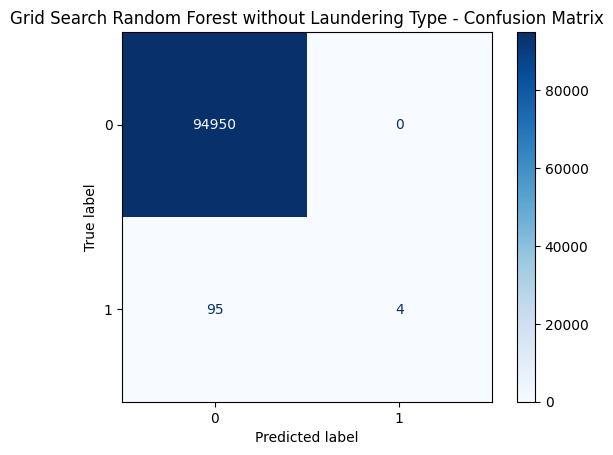

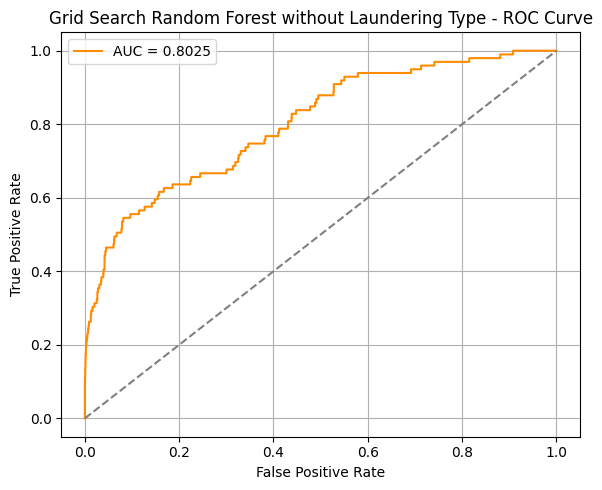

ROC AUC Score: 0.8025
GINI: 0.6049


In [12]:
y_pred = grid_search.predict(X_test.drop('Laundering_type', axis=1))
y_proba = grid_search.predict_proba(X_test.drop('Laundering_type', axis=1))[:, 1]
evaluate_model(y_test, y_pred, y_proba, model_name="Grid Search Random Forest without Laundering Type")

In [13]:
model_pipeline_3 = Pipeline([
    ("preprocessing", preprocessor),
    ("classifier", RandomForestClassifier(random_state=42, n_jobs=-1))
])

param_grid = {
    'classifier__n_estimators': [500, 1000, 1500],
    'classifier__max_depth': [10, 15],
    'classifier__min_samples_split': [40]
}

grid_search = GridSearchCV(
    estimator=model_pipeline_3,
    param_grid=param_grid,
    cv=5,
    scoring='roc_auc',
    verbose=10,
    n_jobs=-1 
)

grid_search.fit(X_train_notype, y_train)

Fitting 5 folds for each of 6 candidates, totalling 30 fits


c:\Users\pawel.drzyzga\Documents\KursStreamlit\kursstreamlit\lib\site-packages\sklearn\base.py:1389: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('preprocessing',
                                        ColumnTransformer(transformers=[('num',
                                                                         Pipeline(steps=[('imputer',
                                                                                          SimpleImputer(strategy='median')),
                                                                                         ('scaler',
                                                                                          RobustScaler())]),
                                                                         Index(['Sender_account', 'Receiver_account', 'Amount', 'Year', 'Month', 'Week',
       'Day'],
      dtype='object')),
                                                                        ('cat',
                                                                         Pipeline(steps=[('imputer',
                                                                                          SimpleImputer(strategy='most_...
                                                                         Index(['Payment_currency', 'Received_currency', 'Sender_bank_location',
       'Receiver_bank_location', 'Payment_type'],
      dtype='object'))])),
                                       ('classifier',
                                        RandomForestClassifier(n_jobs=-1,
                                                               random_state=42))]),
             n_jobs=-1,
             param_grid={'classifier__max_depth': [10, 15],
                         'classifier__min_samples_split': [40],
                         'classifier__n_estimators': [500, 1000, 1500]},
             scoring='roc_auc', verbose=10)

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     94950
           1       1.00      0.04      0.08        99

    accuracy                           1.00     95049
   macro avg       1.00      0.52      0.54     95049
weighted avg       1.00      1.00      1.00     95049



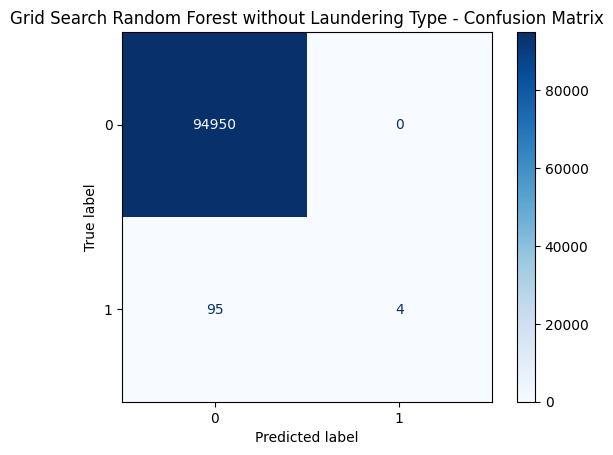

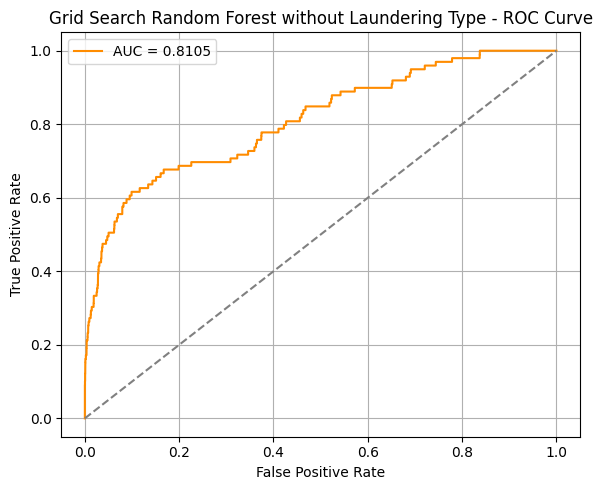

ROC AUC Score: 0.8105
GINI: 0.6210


In [14]:
y_pred = grid_search.predict(X_test.drop('Laundering_type', axis=1))
y_proba = grid_search.predict_proba(X_test.drop('Laundering_type', axis=1))[:, 1]
evaluate_model(y_test, y_pred, y_proba, model_name="Grid Search Random Forest without Laundering Type")

In [15]:
grid_search.best_params_, grid_search.best_score_

({'classifier__max_depth': 15,
  'classifier__min_samples_split': 40,
  'classifier__n_estimators': 1500},
 np.float64(0.8276622117771577))

## Changing from randomforest into XGBoost

In [114]:
model_pipeline_xgb = Pipeline([
    ("preprocessing", preprocessor),
    ("classifier", XGBClassifier(
        random_state=42
        , n_jobs=-1
        , n_estimators = 2000
        , max_depth=3
        , scale_pos_weight=958
        , use_label_encoder=False
        , eval_metric='auc'
        , learning_rate=0.01
        , colsample_bytree=0.5
        ))
])

In [115]:
model_pipeline_xgb.fit(X_train_notype, y_train)

c:\Users\pawel.drzyzga\Documents\KursStreamlit\kursstreamlit\lib\site-packages\xgboost\training.py:183: UserWarning: [17:30:21] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Pipeline(steps=[('preprocessing',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   RobustScaler())]),
                                                  Index(['Sender_account', 'Receiver_account', 'Amount', 'Year', 'Month', 'Week',
       'Day'],
      dtype='object')),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   Ordin...
                               feature_types=None, feature_weights=None,
                               gamma=None, grow_policy=None,
                               importance_type=None,
                               interaction_constraints=None, learning_rate=0.01,
                               max_bin=None, max_cat_threshold=None,
                               max_cat_to_onehot=None, max_delta_step=None,
                               max_depth=3, max_leaves=None,
                               min_child_weight=None, missing=nan,
                               monotone_constraints=None, multi_strategy=None,
                               n_estimators=2000, n_jobs=-1,
                               num_parallel_tree=None, ...))])

              precision    recall  f1-score   support

           0       1.00      0.87      0.93     94950
           1       0.00      0.53      0.01        99

    accuracy                           0.87     95049
   macro avg       0.50      0.70      0.47     95049
weighted avg       1.00      0.87      0.93     95049



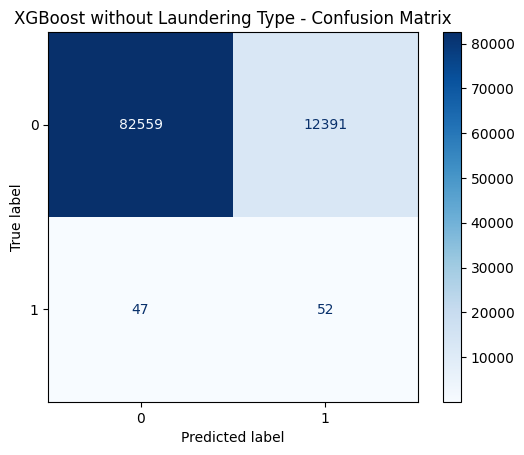

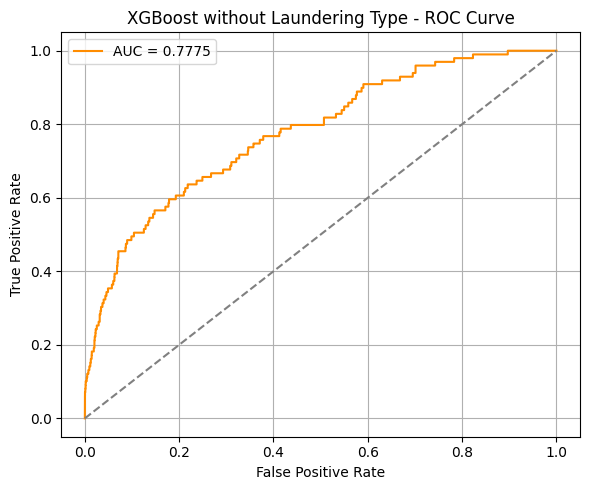

ROC AUC Score: 0.7775
GINI: 0.5550


In [116]:
y_pred = model_pipeline_xgb.predict(X_test.drop('Laundering_type', axis=1))
y_proba = model_pipeline_xgb.predict_proba(X_test.drop('Laundering_type', axis=1))[:, 1]
evaluate_model(y_test, y_pred, y_proba, model_name="XGBoost without Laundering Type")

In [ ]:
model_pipeline_xgb = Pipeline([
    ("preprocessing", preprocessor),
    ("classifier", XGBClassifier(
        random_state=42
        , n_jobs=-1
        , scale_pos_weight=958
        , use_label_encoder=False
        , eval_metric='auc'
        , learning_rate=0.01
        , colsample_bytree=0.5
        , n_estimators=2000
        ))
])

param_grid = {
    'classifier__max_depth': [2, 4],
    'classifier__colsample_bytree': [0.4, 0.8],
    'classifier__reg_alpha': [0, 0.1],
    'classifier__reg_lambda': [1, 10]
}

grid_search = GridSearchCV(
    estimator=model_pipeline_xgb,
    param_grid=param_grid,
    scoring='roc_auc',  
    cv=3,              
    verbose=2,
    n_jobs=-1
)


In [90]:
grid_search.fit(X_train_notype, y_train)

Fitting 3 folds for each of 16 candidates, totalling 48 fits


c:\Users\pawel.drzyzga\Documents\KursStreamlit\kursstreamlit\lib\site-packages\xgboost\training.py:183: UserWarning: [16:44:29] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


GridSearchCV(cv=3,
             estimator=Pipeline(steps=[('preprocessing',
                                        ColumnTransformer(transformers=[('num',
                                                                         Pipeline(steps=[('imputer',
                                                                                          SimpleImputer(strategy='median')),
                                                                                         ('scaler',
                                                                                          RobustScaler())]),
                                                                         Index(['Sender_account', 'Receiver_account', 'Amount', 'Year', 'Month', 'Week',
       'Day'],
      dtype='object')),
                                                                        ('cat',
                                                                         Pipeline(steps=[('imputer',
                                                                                          SimpleImputer(strategy='most_...
                                                      max_depth=None,
                                                      max_leaves=None,
                                                      min_child_weight=None,
                                                      missing=nan,
                                                      monotone_constraints=None,
                                                      multi_strategy=None,
                                                      n_estimators=2000,
                                                      n_jobs=-1,
                                                      num_parallel_tree=None, ...))]),
             n_jobs=-1,
             param_grid={'classifier__colsample_bytree': [0.4, 0.8],
                         'classifier__max_depth': [2, 4],
                         'classifier__reg_alpha': [0, 0.1],
                         'classifier__reg_lambda': [1, 10]},
             scoring='roc_auc', verbose=2)

              precision    recall  f1-score   support

           0       1.00      0.84      0.91     94950
           1       0.00      0.60      0.01        99

    accuracy                           0.84     95049
   macro avg       0.50      0.72      0.46     95049
weighted avg       1.00      0.84      0.91     95049



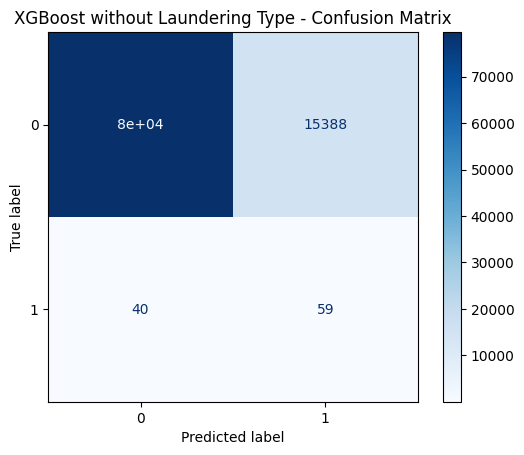

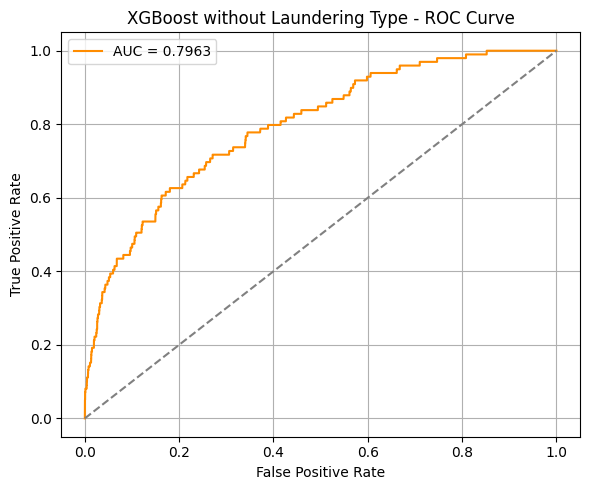

ROC AUC Score: 0.7963
GINI: 0.5927


In [113]:
y_pred = grid_search.predict(X_test.drop('Laundering_type', axis=1))
y_proba = grid_search.predict_proba(X_test.drop('Laundering_type', axis=1))[:, 1]
evaluate_model(y_test, y_pred, y_proba, model_name="XGBoost without Laundering Type")

In [83]:
grid_search.best_params_, grid_search.best_score_

({'classifier__colsample_bytree': 0.4,
  'classifier__max_depth': 4,
  'classifier__reg_alpha': 0.1,
  'classifier__reg_lambda': 10},
 np.float64(0.010042766789709433))

Fitting 3 folds for each of 27 candidates, totalling 81 fits


c:\Users\pawel.drzyzga\Documents\KursStreamlit\kursstreamlit\lib\site-packages\xgboost\training.py:183: UserWarning: [17:30:17] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


              precision    recall  f1-score   support

           0       1.00      0.84      0.91     94950
           1       0.00      0.60      0.01        99

    accuracy                           0.84     95049
   macro avg       0.50      0.72      0.46     95049
weighted avg       1.00      0.84      0.91     95049



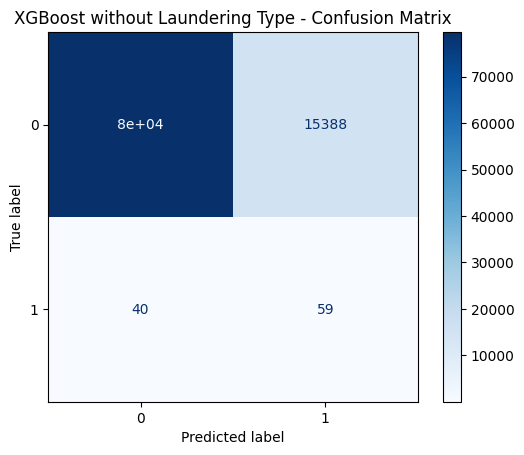

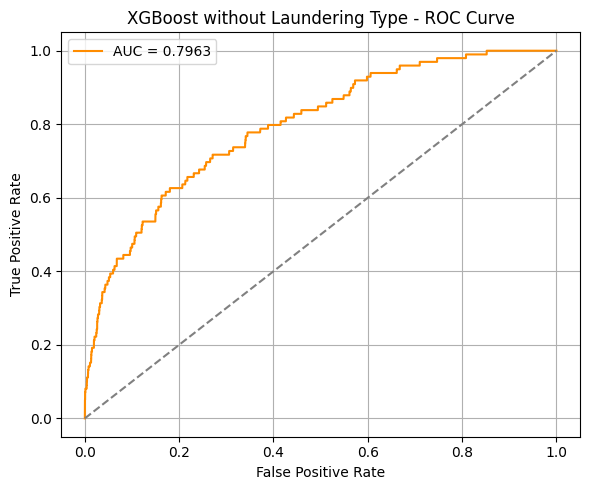

ROC AUC Score: 0.7963
GINI: 0.5927


In [112]:
model_pipeline_xgb = Pipeline([
    ("preprocessing", preprocessor),
    ("classifier", XGBClassifier(
        random_state=42
        , n_jobs=-1
        , scale_pos_weight=958
        , use_label_encoder=False
        , eval_metric='auc'
        , learning_rate=0.01
        , colsample_bytree=0.4
        #, n_estimators=2000
        , max_depth=3
        , reg_alpha=0.1
        , reg_lambda=10
        ))
])

param_grid = {
    'classifier__n_estimators': [500, 1000, 2000]
    , 'classifier__min_child_weight': [1, 5, 10]
    , 'classifier__subsample': [0.5, 0.7, 1.0]
}

grid_search = GridSearchCV(
    estimator=model_pipeline_xgb,
    param_grid=param_grid,
    scoring='roc_auc',  
    cv=3,             
    verbose=2,
    n_jobs=-1
)

grid_search.fit(X_train_notype, y_train)

y_pred = grid_search.predict(X_test.drop('Laundering_type', axis=1))
y_proba = grid_search.predict_proba(X_test.drop('Laundering_type', axis=1))[:, 1]
evaluate_model(y_test, y_pred, y_proba, model_name="XGBoost without Laundering Type")

In [94]:
grid_search.best_params_, grid_search.best_score_

({'classifier__min_child_weight': 1,
  'classifier__n_estimators': 500,
  'classifier__subsample': 1.0},
 np.float64(0.7862189198875186))

Fitting 5 folds for each of 3 candidates, totalling 15 fits


c:\Users\pawel.drzyzga\Documents\KursStreamlit\kursstreamlit\lib\site-packages\xgboost\training.py:183: UserWarning: [17:20:28] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


              precision    recall  f1-score   support

           0       1.00      0.92      0.96     94950
           1       0.01      0.44      0.01        99

    accuracy                           0.92     95049
   macro avg       0.50      0.68      0.49     95049
weighted avg       1.00      0.92      0.96     95049



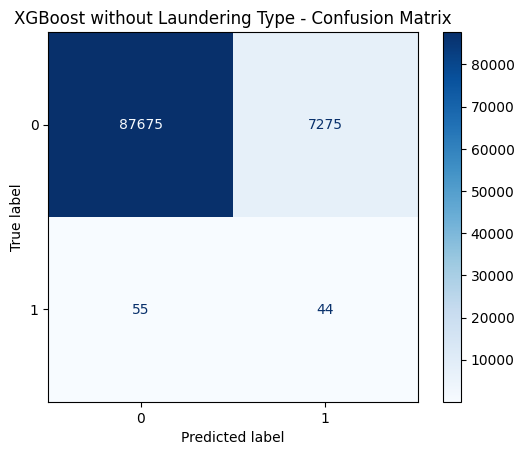

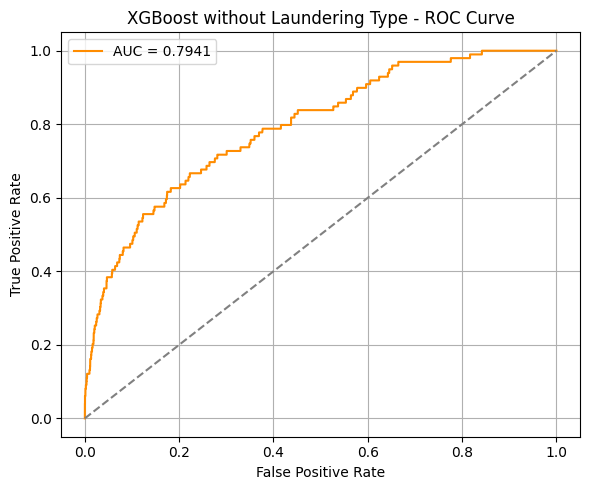

ROC AUC Score: 0.7941
GINI: 0.5882


In [111]:
model_pipeline_xgb = Pipeline([
    ("preprocessing", preprocessor),
    ("classifier", XGBClassifier(
        random_state=42
        , n_jobs=-1
        , scale_pos_weight=958
        , use_label_encoder=False
        , eval_metric='auc'
        , learning_rate=0.01
        , colsample_bytree=0.4
        , n_estimators=500
        , max_depth=3
        , reg_alpha=0.1
        , reg_lambda=10
        ))
])

param_grid = {
    'classifier__scale_pos_weight': [958/2, 958, 958*2]
}

grid_search = GridSearchCV(
    estimator=model_pipeline_xgb,
    param_grid=param_grid,
    scoring='roc_auc',  
    cv=5,             
    verbose=2,
    n_jobs=-1
)

grid_search.fit(X_train_notype, y_train)

y_pred = grid_search.predict(X_test.drop('Laundering_type', axis=1))
y_proba = grid_search.predict_proba(X_test.drop('Laundering_type', axis=1))[:, 1]
evaluate_model(y_test, y_pred, y_proba, model_name="XGBoost without Laundering Type")

In [96]:
grid_search.best_score_, grid_search.best_params_

(np.float64(0.7956298895012389), {'classifier__scale_pos_weight': 479.0})

## Analyzing the best model

c:\Users\pawel.drzyzga\Documents\KursStreamlit\kursstreamlit\lib\site-packages\xgboost\training.py:183: UserWarning: [18:45:16] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


              precision    recall  f1-score   support

           0       1.00      0.84      0.91     94950
           1       0.00      0.60      0.01        99

    accuracy                           0.84     95049
   macro avg       0.50      0.72      0.46     95049
weighted avg       1.00      0.84      0.91     95049



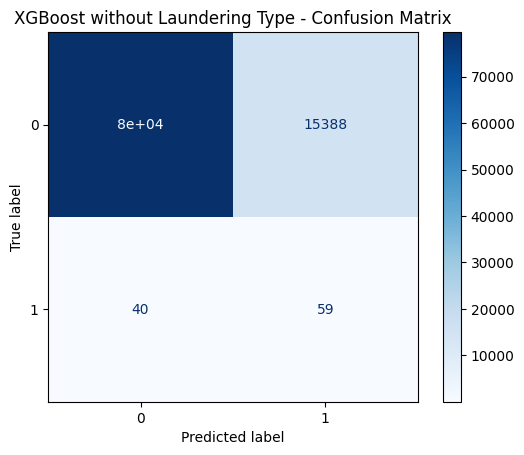

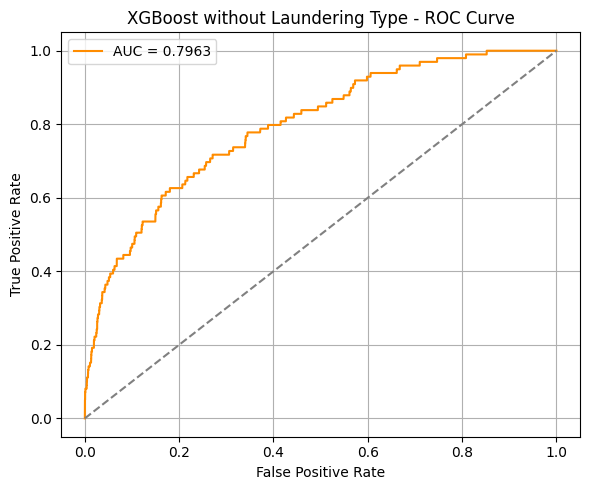

ROC AUC Score: 0.7963
GINI: 0.5927


In [53]:
model_pipeline_xgb = Pipeline([
    ("preprocessing", preprocessor),
    ("classifier", XGBClassifier(
        random_state=42
        , n_jobs=-1
        , scale_pos_weight=958
        , use_label_encoder=False
        , eval_metric='auc'
        , learning_rate=0.01
        , colsample_bytree=0.4
        , n_estimators=500
        , max_depth=3
        , reg_alpha=0.1
        , reg_lambda=10
        ))
])

model_pipeline_xgb.fit(X_train_notype, y_train)

y_pred = model_pipeline_xgb.predict(X_test.drop('Laundering_type', axis=1))
y_proba = model_pipeline_xgb.predict_proba(X_test.drop('Laundering_type', axis=1))[:, 1]
evaluate_model(y_test, y_pred, y_proba, model_name="XGBoost without Laundering Type")

In [133]:
feature_names = model_pipeline_xgb.named_steps["preprocessing"].get_feature_names_out()
feature_names

array(['num__Sender_account', 'num__Receiver_account', 'num__Amount',
       'num__Year', 'num__Month', 'num__Week', 'num__Day',
       'cat__Payment_currency', 'cat__Received_currency',
       'cat__Sender_bank_location', 'cat__Receiver_bank_location',
       'cat__Payment_type'], dtype=object)

In [136]:
feature_names = [re.sub(r'num__', '', re.sub(r'cat__', '', i)) for i in feature_names]
feature_names

['Sender_account',
 'Receiver_account',
 'Amount',
 'Year',
 'Month',
 'Week',
 'Day',
 'Payment_currency',
 'Received_currency',
 'Sender_bank_location',
 'Receiver_bank_location',
 'Payment_type']

In [137]:
names = {f"f{i}": name for i, name in enumerate(feature_names)}
names

{'f0': 'Sender_account',
 'f1': 'Receiver_account',
 'f2': 'Amount',
 'f3': 'Year',
 'f4': 'Month',
 'f5': 'Week',
 'f6': 'Day',
 'f7': 'Payment_currency',
 'f8': 'Received_currency',
 'f9': 'Sender_bank_location',
 'f10': 'Receiver_bank_location',
 'f11': 'Payment_type'}

In [139]:
importance = model_pipeline_xgb.named_steps['classifier'].get_booster().get_score(importance_type='gain')
importance

{'f0': 1502.1004638671875,
 'f1': 2249.304443359375,
 'f2': 4988.79248046875,
 'f3': 1031.83056640625,
 'f4': 1108.3616943359375,
 'f5': 1358.4945068359375,
 'f6': 3310.716796875,
 'f7': 3131.67529296875,
 'f8': 5941.66259765625,
 'f9': 2271.736328125,
 'f10': 5333.9140625,
 'f11': 9353.9306640625}

In [141]:
feature_values = {names[k]: round(v,2) for k, v in importance.items() if k in names}
feature_values

{'Sender_account': 1502.1,
 'Receiver_account': 2249.3,
 'Amount': 4988.79,
 'Year': 1031.83,
 'Month': 1108.36,
 'Week': 1358.49,
 'Day': 3310.72,
 'Payment_currency': 3131.68,
 'Received_currency': 5941.66,
 'Sender_bank_location': 2271.74,
 'Receiver_bank_location': 5333.91,
 'Payment_type': 9353.93}

In [146]:
total = sum(feature_values.values())
feature_values_percent = {k: str(round(v / total * 100, 2))+'%' for k, v in feature_values.items()}
feature_values_percent

{'Sender_account': '3.61%',
 'Receiver_account': '5.41%',
 'Amount': '12.0%',
 'Year': '2.48%',
 'Month': '2.67%',
 'Week': '3.27%',
 'Day': '7.96%',
 'Payment_currency': '7.53%',
 'Received_currency': '14.29%',
 'Sender_bank_location': '5.46%',
 'Receiver_bank_location': '12.83%',
 'Payment_type': '22.49%'}